In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pipeline import dataset
import joblib
import optuna

from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from utils import acc, precis, recall, f1
from SHAP import tree_explainer, plot_shap_summary, plot_dependence_top2, plot_force, plot_feature_importance

import warnings
warnings.filterwarnings('ignore')

c:\Users\Nabil\miniconda3\envs\KP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_CONF = [
  {
    "name": "mojokerto", 
    "tif_path": "Data/mojokerto/feature11", 
    "label_path": "Data/mojokerto/label/label1.tif"
  },
  {
    "name": "samodra_A", 
    "tif_path": "Data/samodra/A", 
    "label_path": "Data/samodra/label/A/label.tif"
  },
  {
    "name": "samodra_B", 
    "tif_path": "Data/samodra/B", 
    "label_path": "Data/samodra/label/B/label.tif"
  }
]

In [3]:
df_list = []
for config in DATASET_CONF:
    train_df, val_df = dataset.get_ML_data(config["tif_path"], config["label_path"])
    df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
    df['lokasi'] = config["name"]
    df_list.append(df)

final_df = pd.concat(df_list, axis=0, ignore_index=True)

(420, 11) (180, 11) (420, 1) (180, 1)
(210, 11) (91, 11) (210, 1) (91, 1)
(356, 11) (353, 11) (356, 1) (353, 1)


In [4]:
final_df.to_csv("Data/combined_dataset.csv", index=False)

In [5]:
df_mjk = final_df[final_df['lokasi'] == 'mojokerto']
df_sam_A = final_df[final_df['lokasi'] == 'samodra_A']
df_sam_B = final_df[final_df['lokasi'] == 'samodra_B']

## EDA

In [6]:
print(final_df['lokasi'].value_counts())

lokasi
samodra_B    709
mojokerto    600
samodra_A    301
Name: count, dtype: int64


In [7]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   aspect   1610 non-null   float64
 1   elevasi  1610 non-null   float64
 2   geologi  1610 non-null   float64
 3   jalan    1610 non-null   float64
 4   landuse  1610 non-null   float64
 5   plan     1610 non-null   float64
 6   prof     1610 non-null   float64
 7   slope    1610 non-null   float64
 8   spi      1610 non-null   float64
 9   sungai   1610 non-null   float64
 10  twi      1610 non-null   float64
 11  label    1610 non-null   float64
 12  lokasi   1610 non-null   object 
dtypes: float64(12), object(1)
memory usage: 163.6+ KB


In [8]:
df_mjk.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.491289,0.211154,0.519556,0.090227,0.190370,0.751346,0.405636,0.329745,0.013379,0.241834,0.240263,0.500000
std,0.286970,0.144512,0.224792,0.138770,0.248439,0.077187,0.078731,0.244734,0.082509,0.217234,0.170727,0.500417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001487,-0.000010,0.000000,-0.022739,0.000000
25%,0.245817,0.113784,0.400000,0.016287,0.000000,0.718794,0.372366,0.099455,0.000510,0.065547,0.126039,0.000000
50%,0.490214,0.185420,0.466667,0.042287,0.000000,0.750851,0.406806,0.291510,0.001696,0.169003,0.204014,0.500000
75%,0.735990,0.284370,0.733333,0.094711,0.333333,0.786124,0.436717,0.516400,0.004479,0.380206,0.299071,1.000000
max,1.000000,1.022069,1.000000,1.032598,1.000000,1.118500,1.000000,1.000000,1.455557,1.000000,1.000000,1.000000


In [9]:
df_sam_A.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,3.010000e+02,301.000000,301.000000
mean,0.466426,0.515968,0.633001,0.177558,0.545455,0.538814,0.398993,0.349994,0.648290,1.092193e-01,0.146746,0.637874
std,0.288417,0.257006,0.384173,0.180753,0.270292,0.080490,0.124379,0.219412,0.143375,1.619689e-01,0.141729,0.481415
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.032256,0.000000,-0.310330,-3.255015e-09,-0.001069,0.000000
25%,0.219564,0.309719,0.200000,0.051666,0.363636,0.515440,0.322581,0.167901,0.594833,2.316304e-02,0.065206,0.000000
50%,0.450096,0.570258,0.833333,0.113765,0.545455,0.539193,0.387097,0.333333,0.641793,4.635826e-02,0.101016,1.000000
75%,0.702277,0.732631,1.000000,0.224764,0.727273,0.570072,0.451614,0.520988,0.720669,1.196435e-01,0.172100,1.000000
max,1.002813,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.151519,1.000000e+00,1.000000,1.000000


In [10]:
df_sam_B.describe()

,aspect,elevasi,geologi,jalan,landuse,plan,prof,slope,spi,sungai,twi,label
count,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000
mean,0.486124,0.438213,0.574706,0.229656,0.503398,0.410034,0.546544,0.451818,0.639929,0.153834,0.143937,0.421721
std,0.298935,0.232162,0.388338,0.224082,0.371390,0.088122,0.129622,0.201618,0.113245,0.157326,0.112138,0.494183
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.139537,-0.218749,-0.006961,0.000000,0.000000,-0.009639,0.000000
25%,0.220028,0.248534,0.166667,0.059327,0.090909,0.378737,0.468750,0.310905,0.601380,0.044368,0.076506,0.000000
50%,0.465927,0.429590,0.800000,0.154916,0.545455,0.408637,0.562500,0.450116,0.647318,0.109418,0.114458,0.000000
75%,0.749656,0.616148,1.000000,0.337891,0.818182,0.438538,0.625000,0.596288,0.699480,0.211164,0.166868,1.000000
max,1.000560,1.021110,1.000000,1.162644,1.000000,1.000000,1.000000,1.039443,1.035868,1.000000,1.000000,1.000000


In [11]:
features = [col for col in df.columns if col not in ['label', 'lokasi']]
cat_cols = ['geologi', 'landuse']
num_cols = [col for col in features if col not in cat_cols]
locations = df['lokasi'].unique()

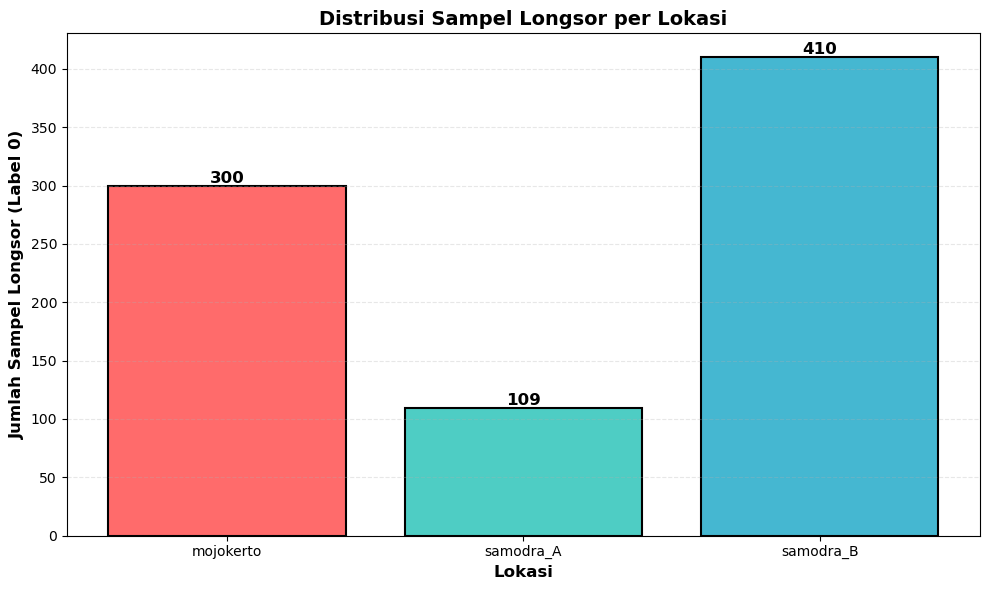

In [ ]:
label_0_counts = final_df[final_df['label'] == 0].groupby('lokasi').size()

plt.figure(figsize=(10, 6))
bars = plt.bar(label_0_counts.index, label_0_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Lokasi', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel Longsor', fontsize=12, fontweight='bold')
plt.title('Distribusi Sampel Longsor per Lokasi', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

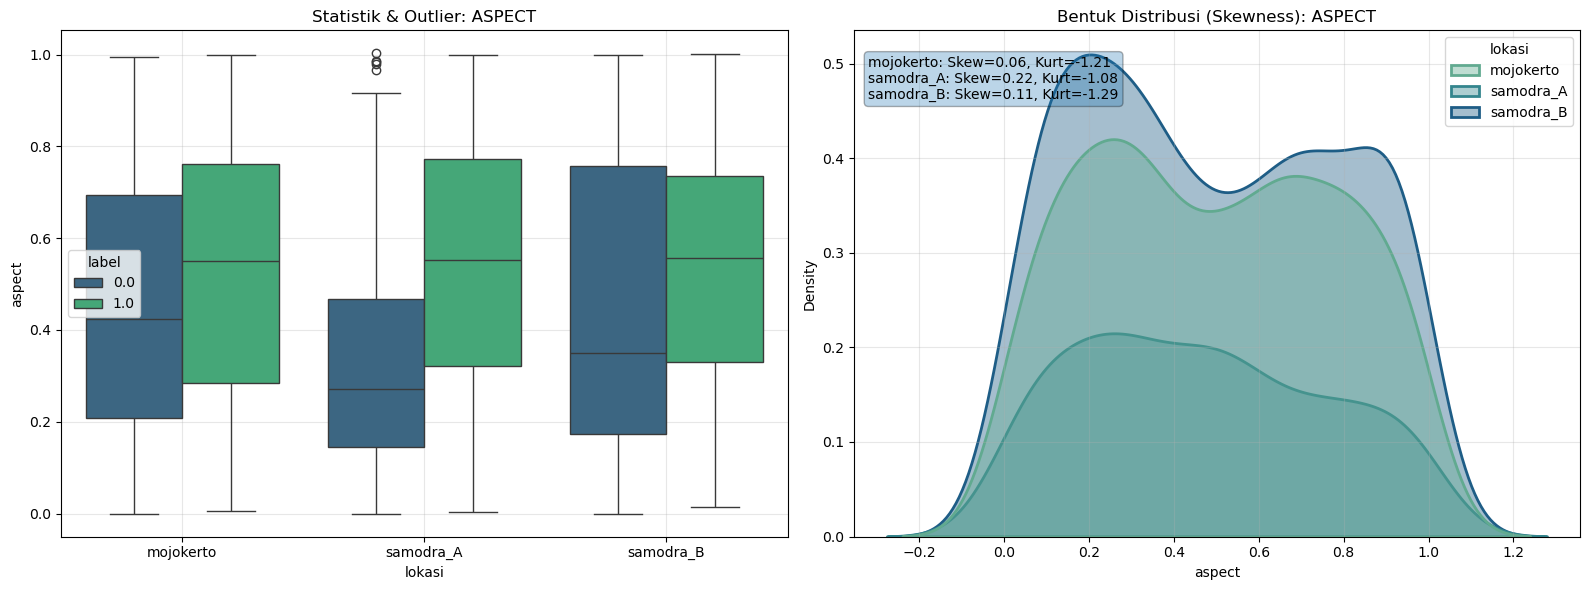

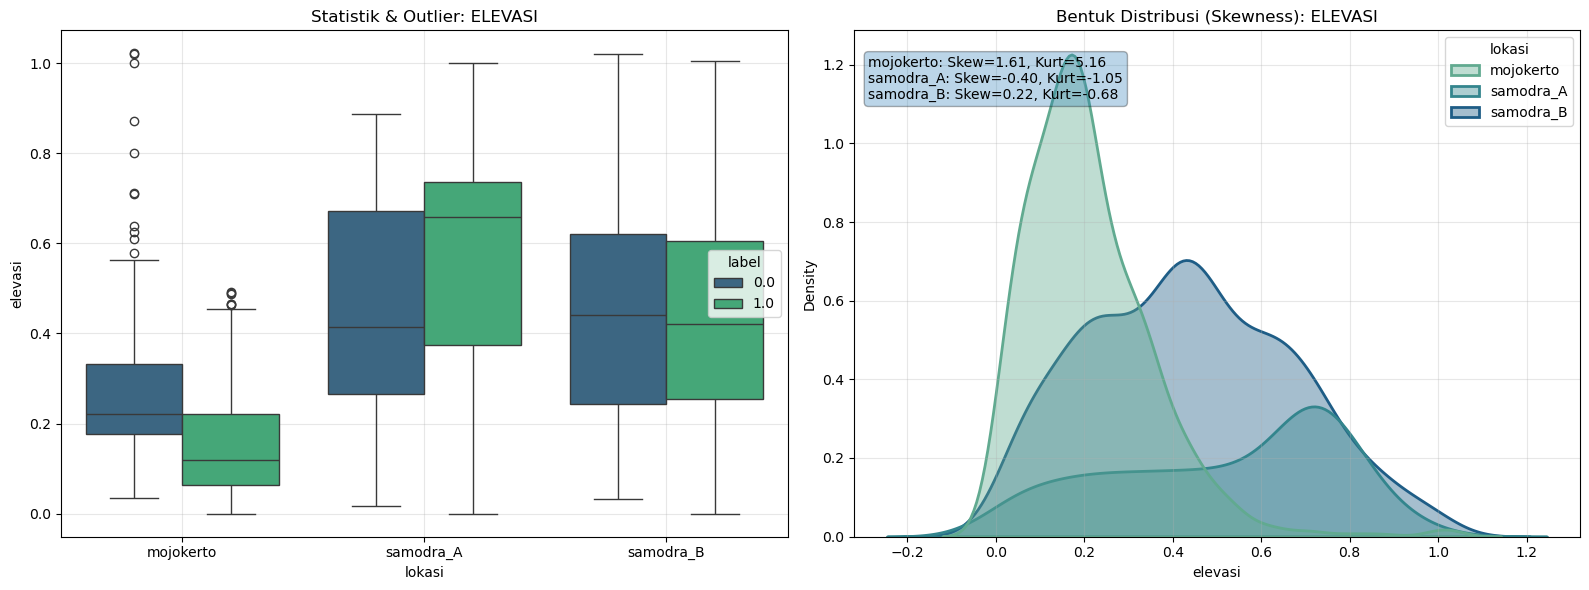

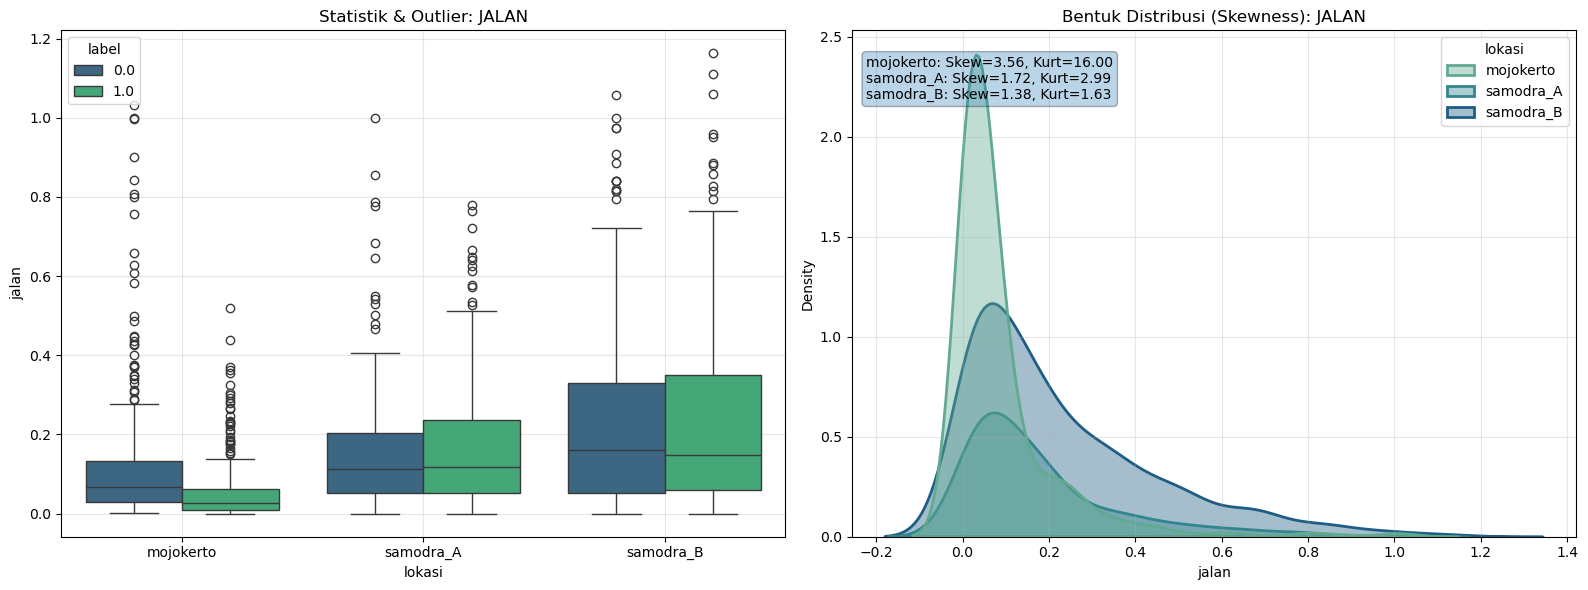

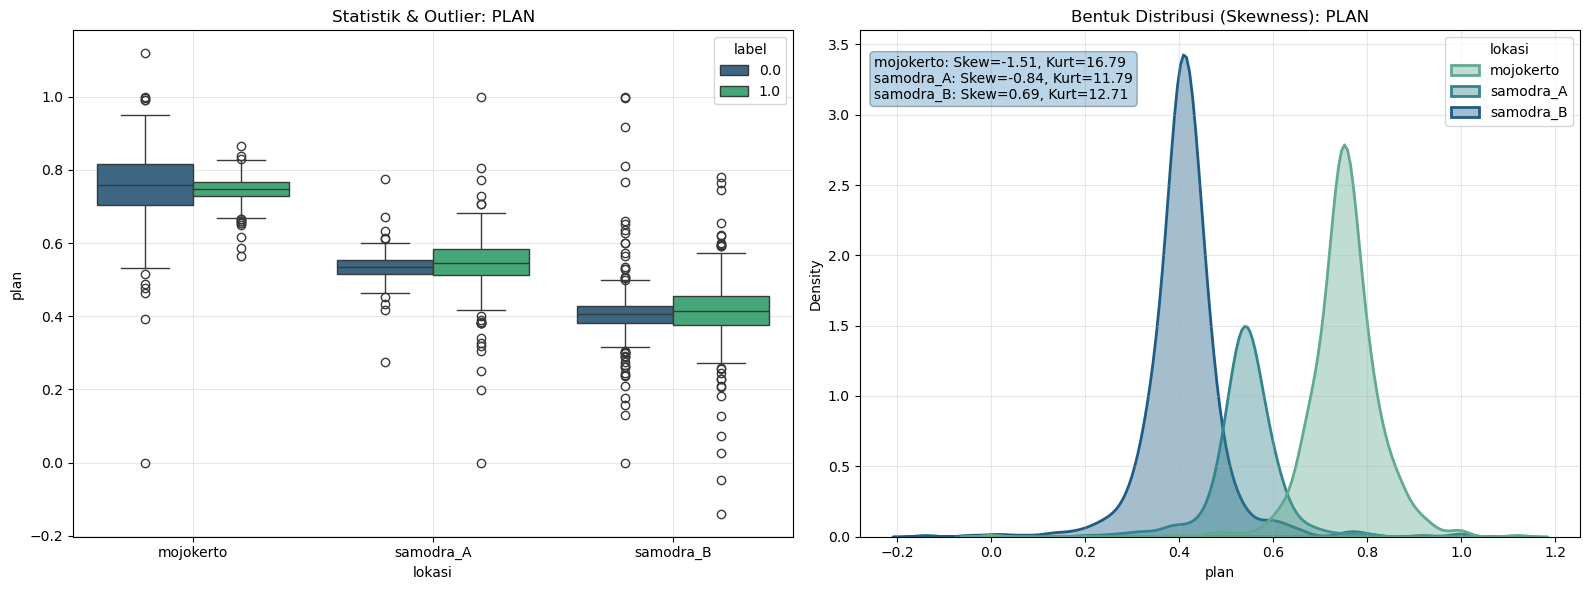

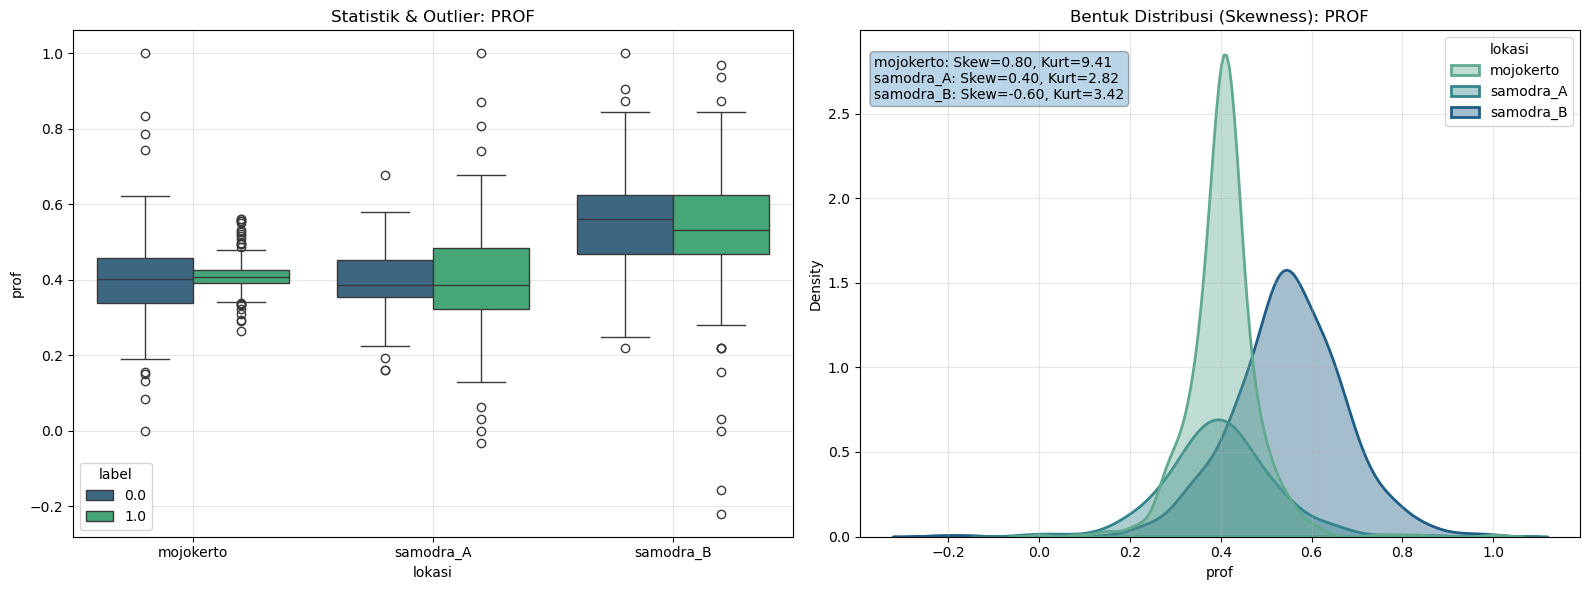

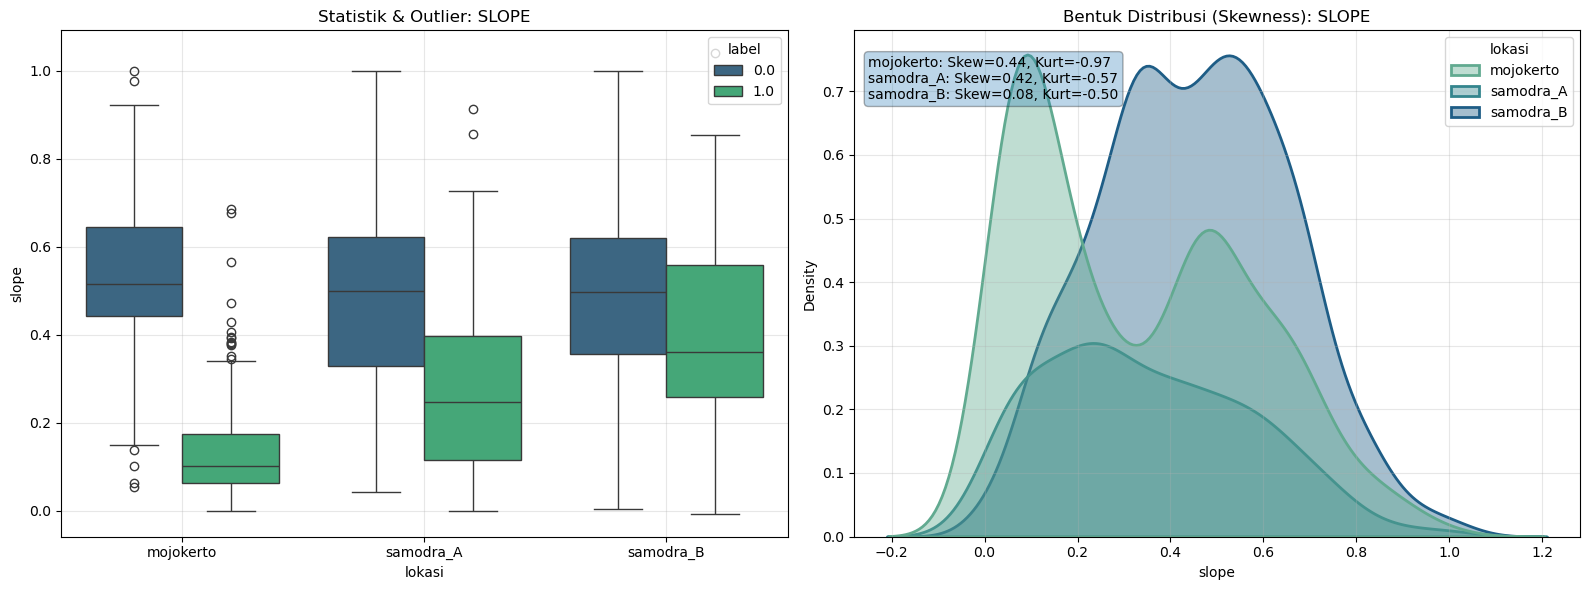

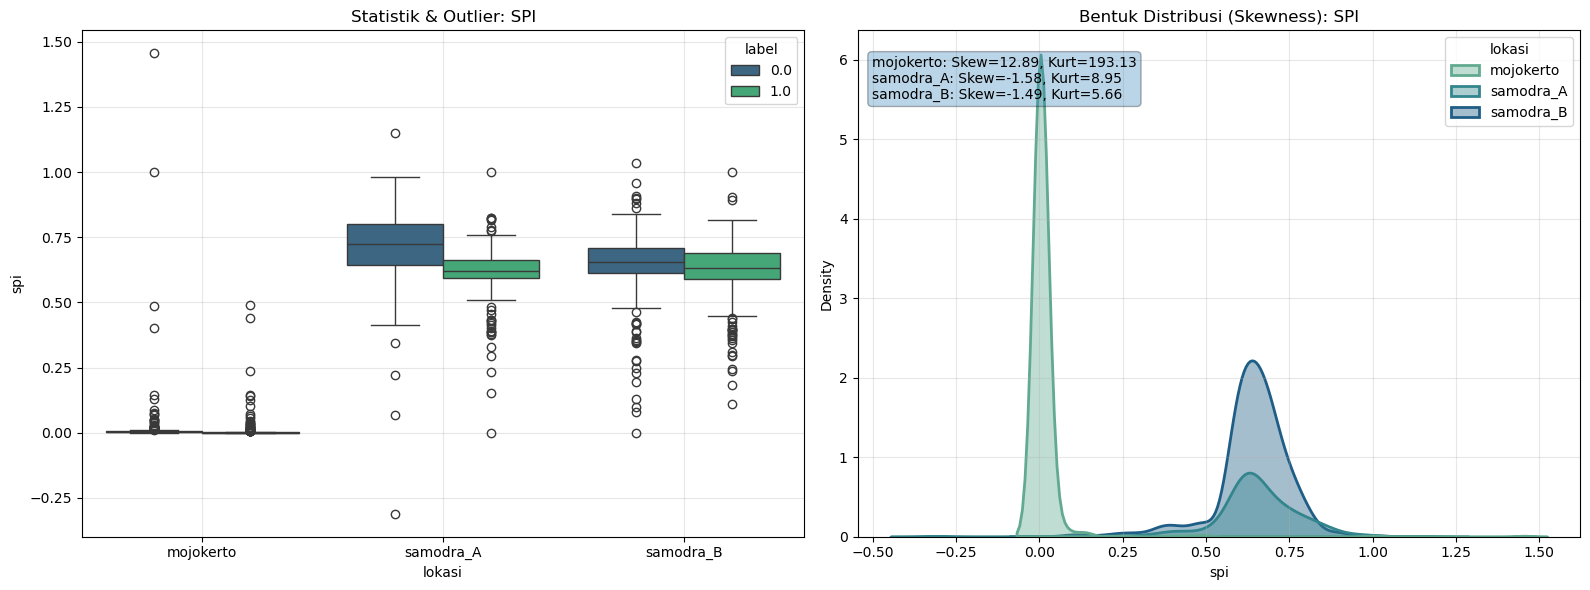

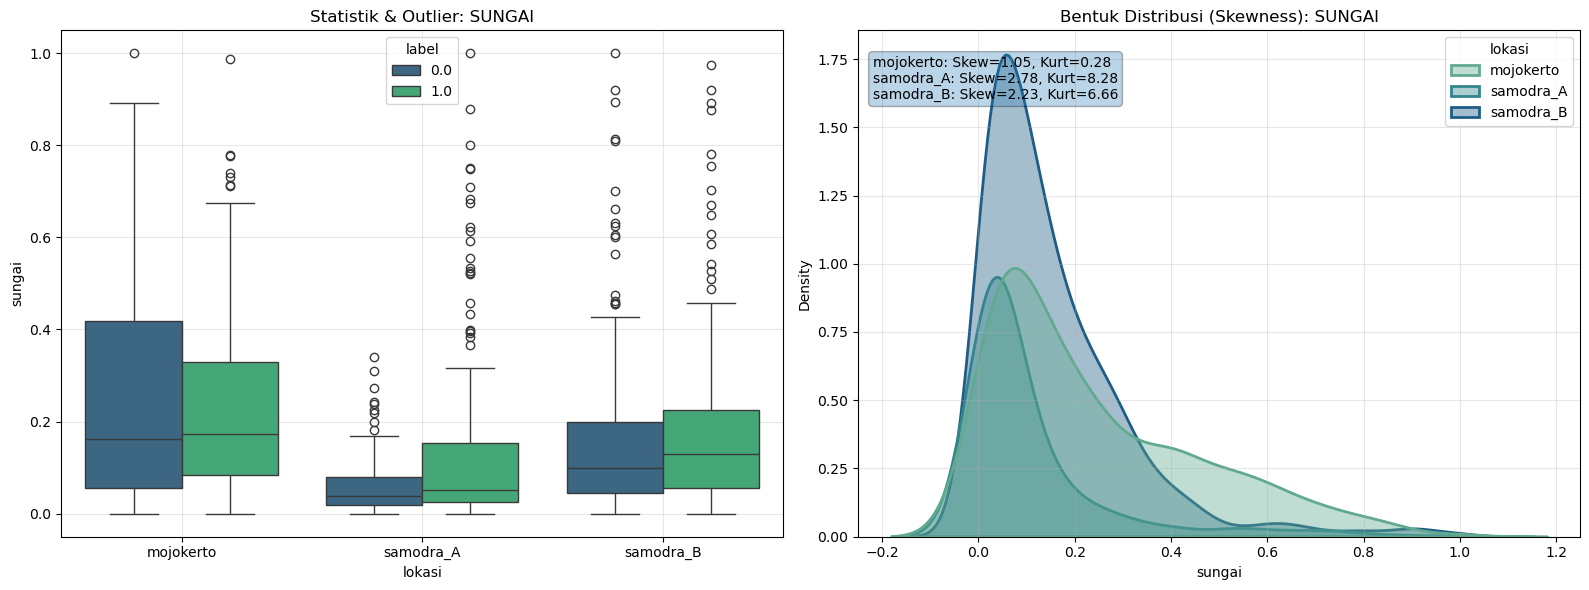

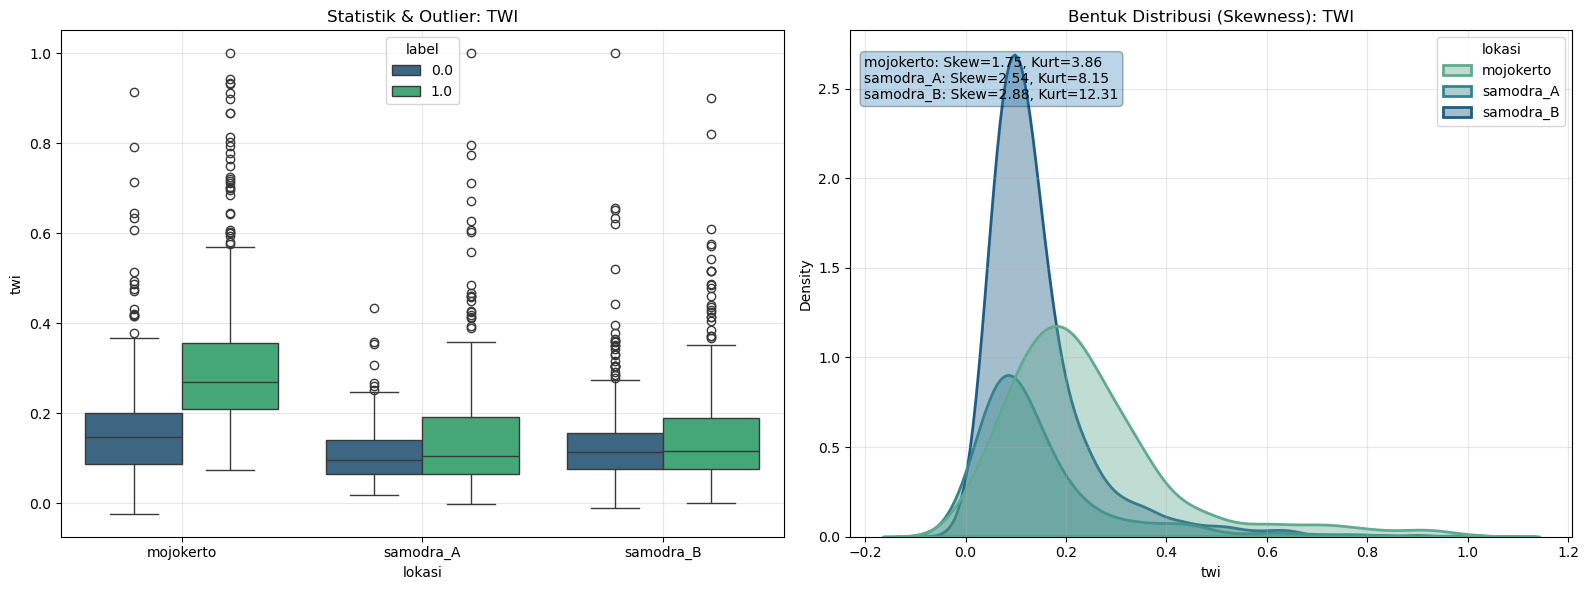

In [275]:
for col in num_cols:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot( data=final_df, x='lokasi', y=col, hue='label', palette='viridis')
    plt.title(f'Statistik & Outlier: {col.upper()}')
    plt.grid(True, alpha=0.3)
    plt.legend(title='label')

    plt.subplot(1, 2, 2)
    sns.kdeplot( data=final_df, x=col, hue='lokasi', fill=True, palette='crest', alpha=0.4, linewidth=2)

    text_lines = []
    for loc in final_df['lokasi'].unique():
        vals = final_df.loc[final_df['lokasi'] == loc, col].dropna()
        sk = skew(vals)
        ku = kurtosis(vals, fisher=True)
        text_lines.append(f"{loc}: Skew={sk:.2f}, Kurt={ku:.2f}")

    text = "\n".join(text_lines)

    plt.text(
        0.02, 0.95,
        text,
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(boxstyle="round", alpha=0.3)
    )

    plt.title(f'Bentuk Distribusi (Skewness): {col.upper()}')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [276]:
def scatter(df,features, ref_col='elevasi', label_col='label'):
    features = [c for c in features if c != ref_col]

    n_plots = len(features)
    n_rows = np.ceil(n_plots / 3).astype(int)

    plt.figure(figsize=(18, 12))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, 3, i)

        sns.scatterplot(
            data=df,
            x=col,
            y=ref_col,
            hue=label_col,
            style=label_col,
            s=80,
            alpha=0.7,
            palette='deep'
        )

        plt.title(f'{col} vs {ref_col}')
        plt.grid(True, alpha=0.3)
        plt.legend(title=label_col)

    plt.suptitle(
        f'Scatter Plot Semua Fitur Numerik vs {ref_col}\n'
        '(Analisis Separasi Kelas)',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


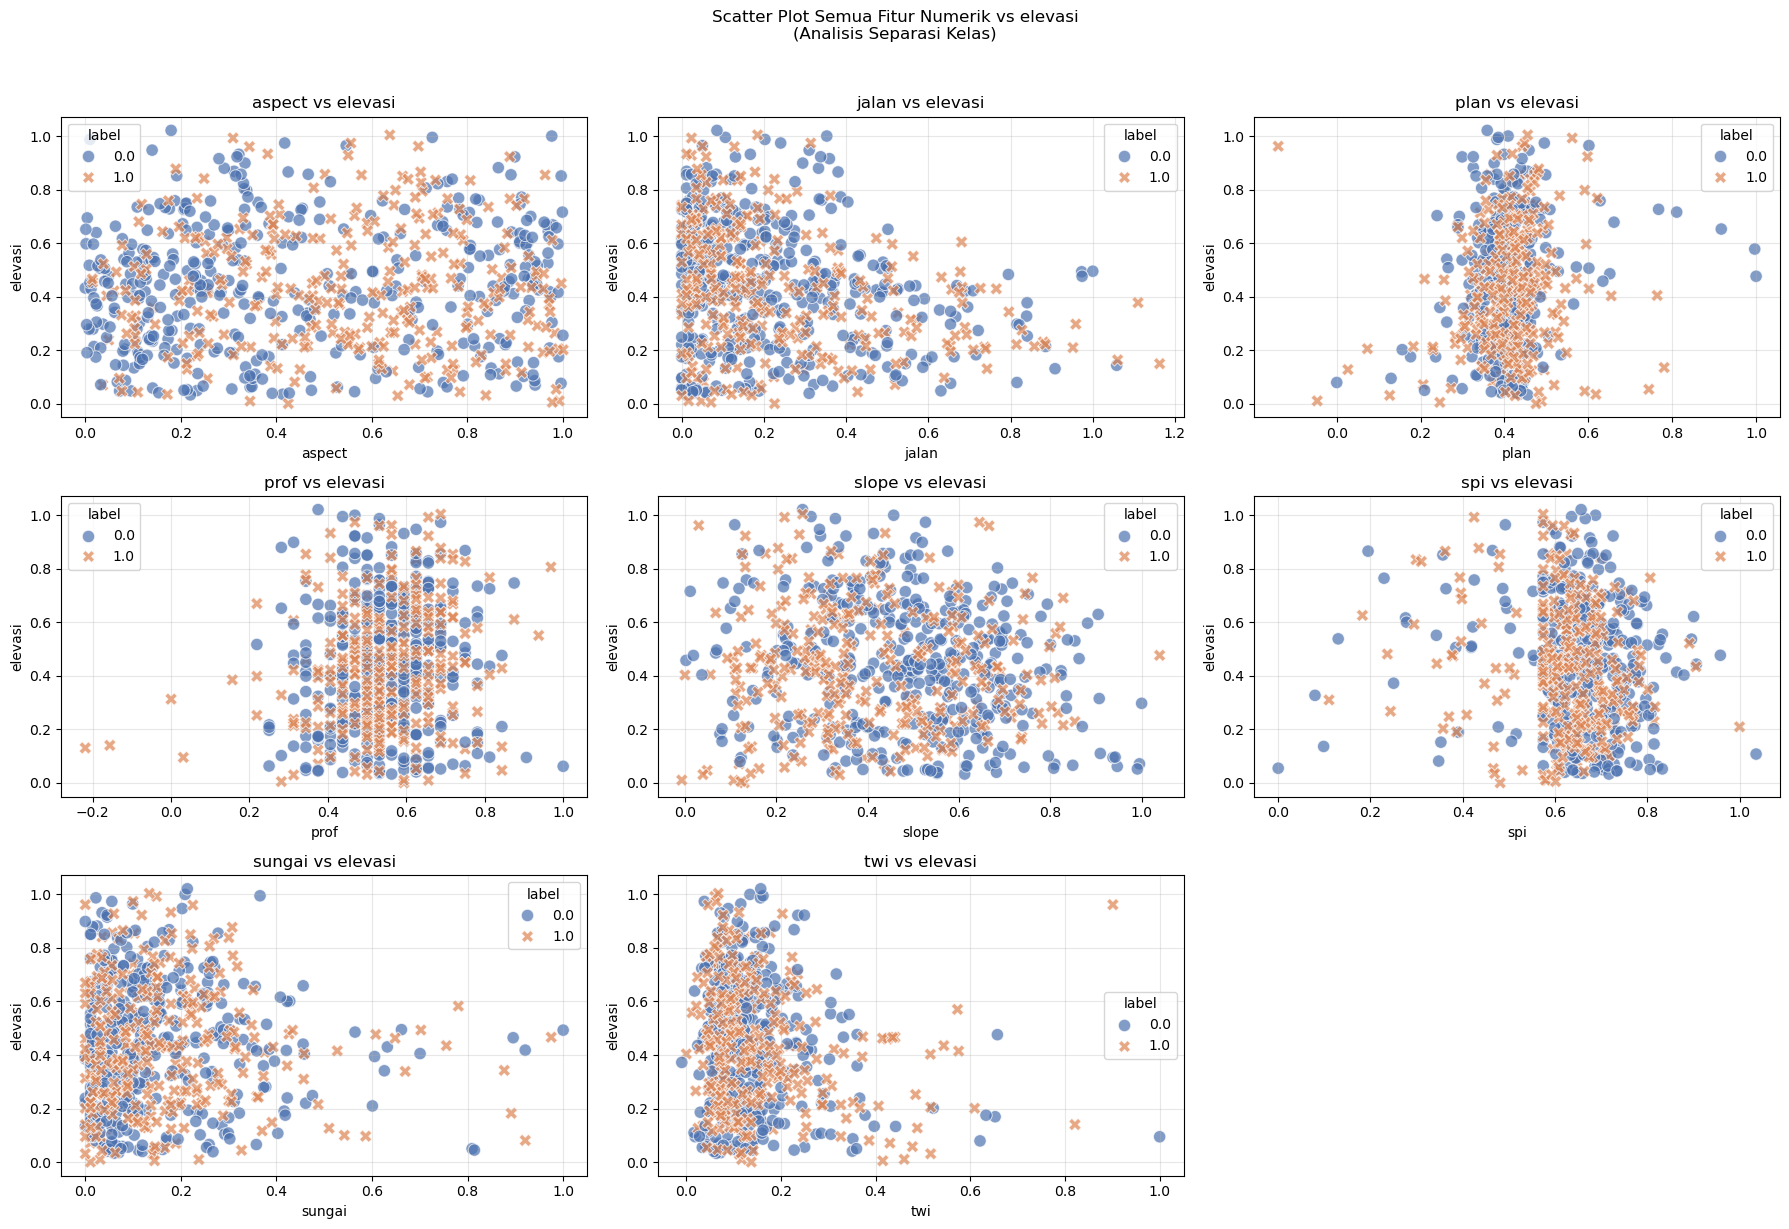

In [277]:
scatter(df_sam_B, num_cols, ref_col='elevasi')


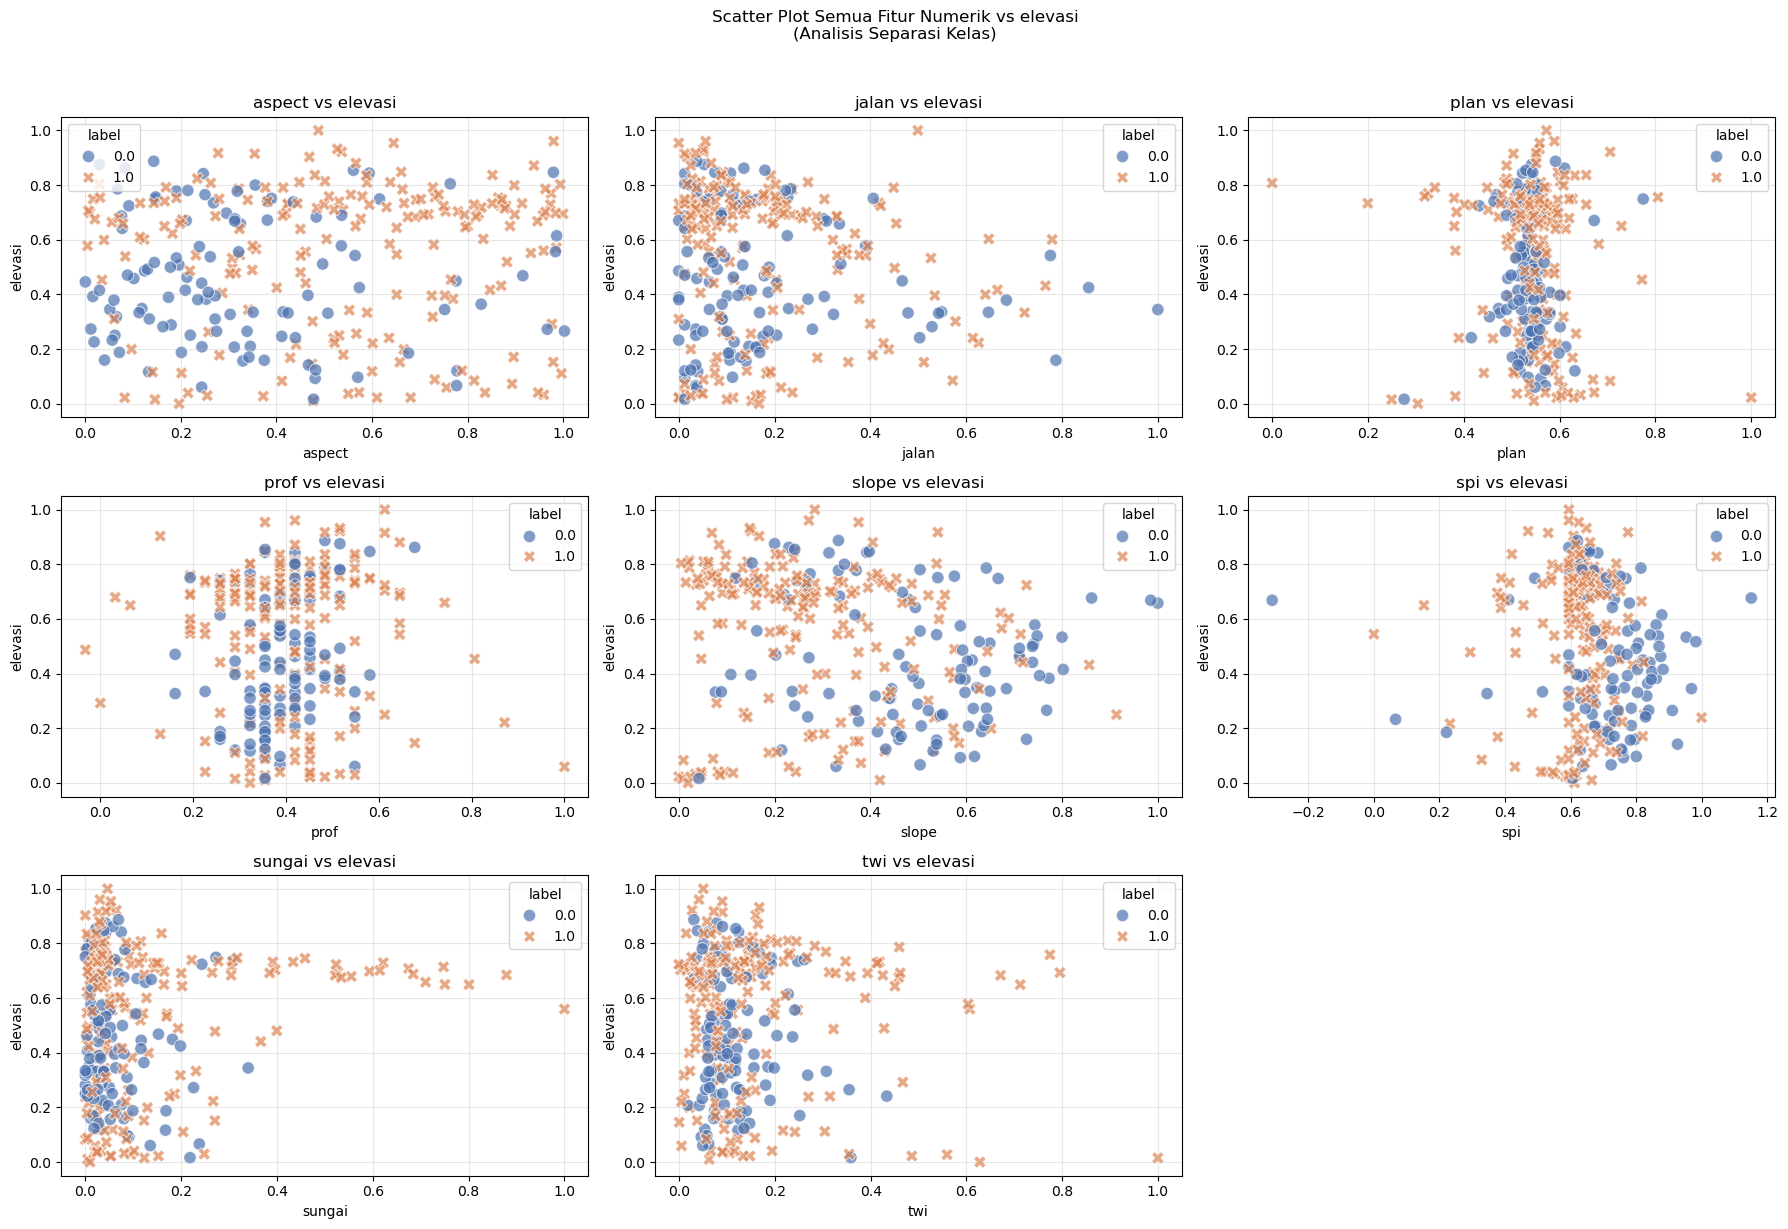

In [278]:
scatter(df_sam_A, num_cols, ref_col='elevasi')

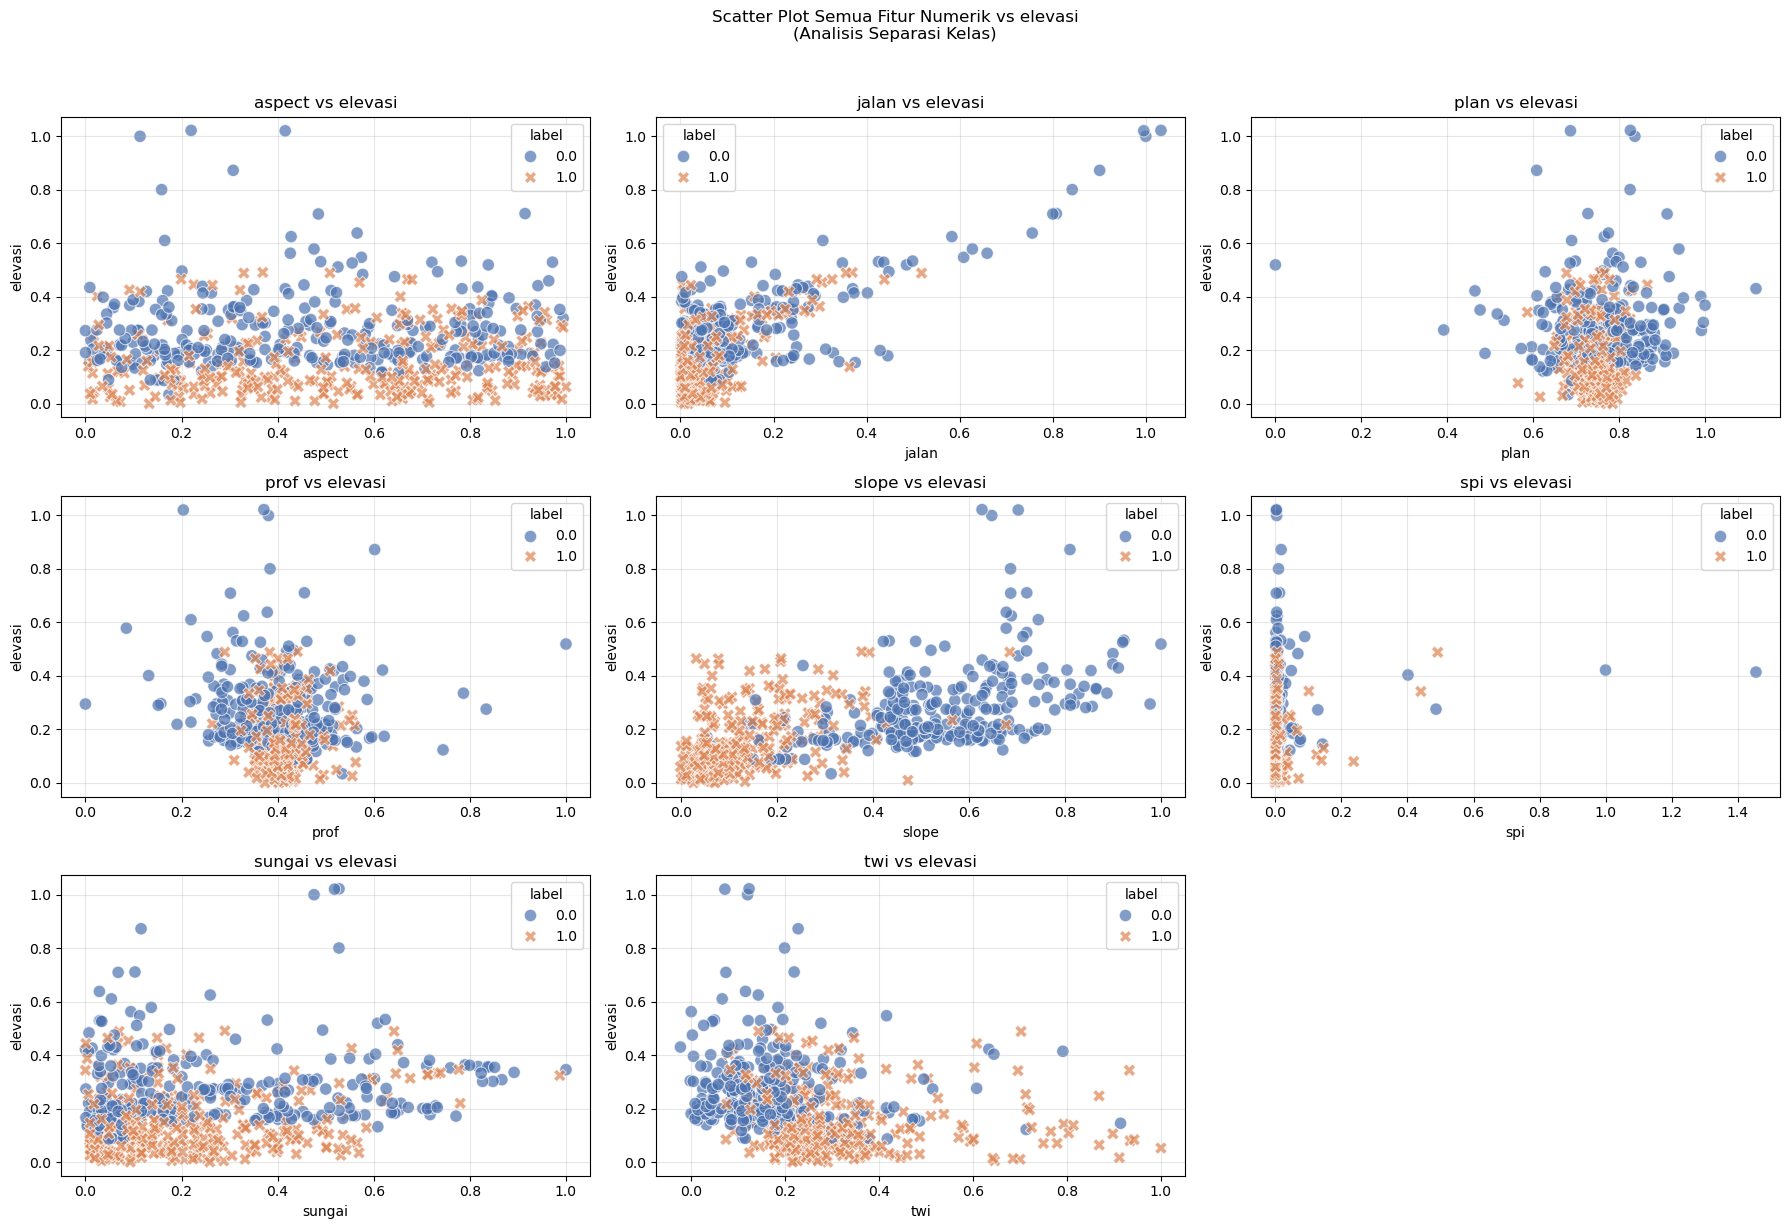

In [279]:
scatter(df_mjk, num_cols, ref_col='elevasi')

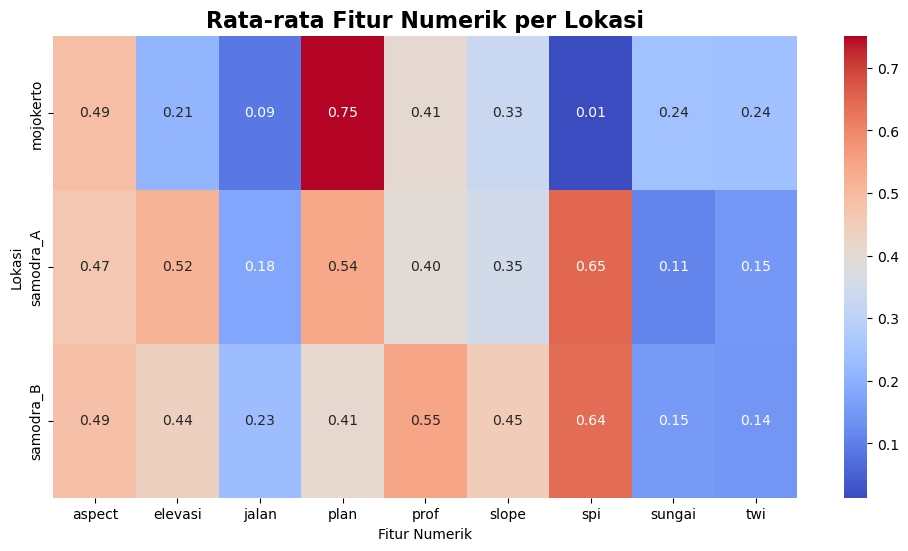

In [280]:
# sebaran data numerik per lokasi
avg = final_df.groupby('lokasi')[num_cols].mean()
plt.figure(figsize=(12, 6))
sns.heatmap(avg, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Rata-rata Fitur Numerik per Lokasi', fontsize=16, fontweight='bold')
plt.xlabel('Fitur Numerik')
plt.ylabel('Lokasi')
plt.show()


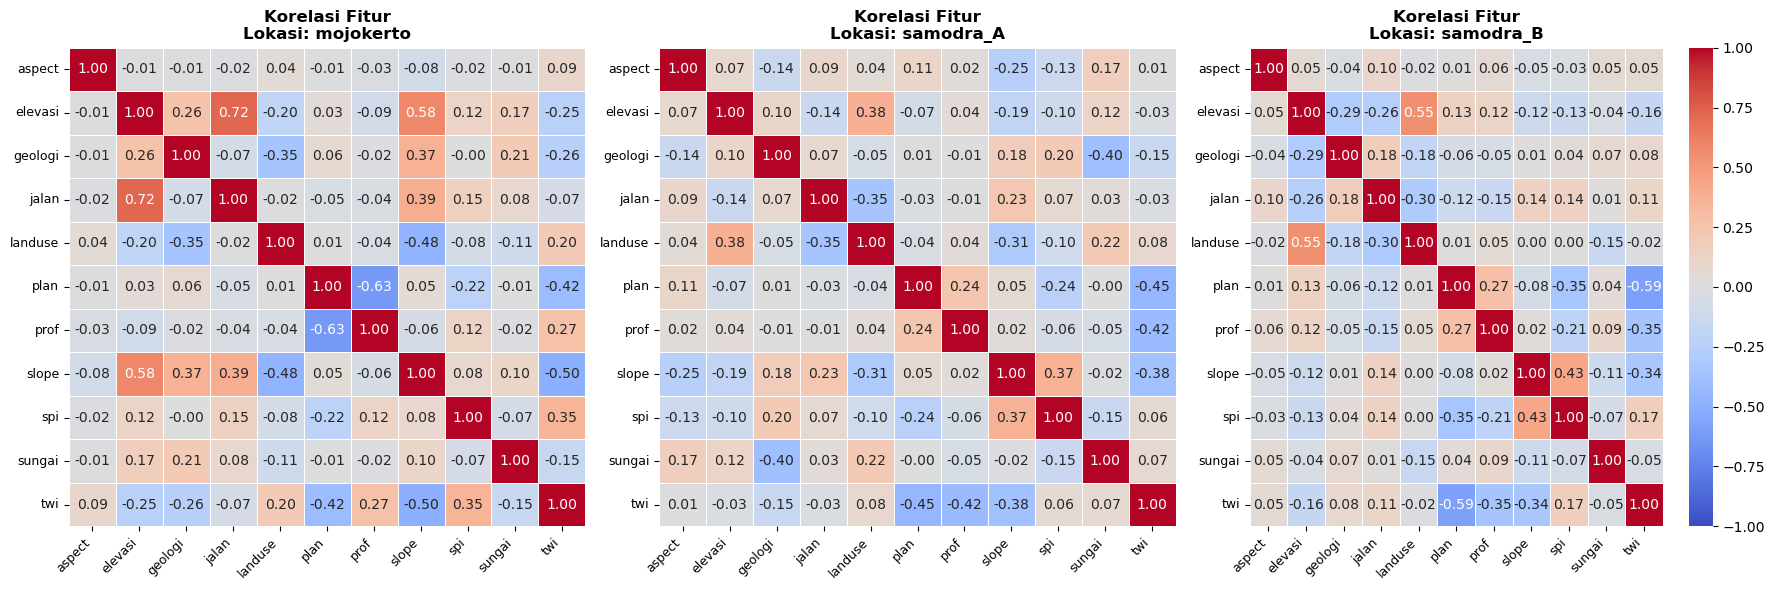

In [281]:
locations = final_df['lokasi'].unique()

plt.figure(figsize=(6 * len(locations), 6))
for i, loc in enumerate(locations, 1):
    df_subset = final_df[final_df['lokasi'] == loc][features]

    corr = df_subset.corr()
    plt.subplot(1, len(locations), i)

    sns.heatmap(
        corr,
        annot=True,           
        fmt=".2f",            
        cmap='coolwarm',
        vmin=-1, vmax=1,
        center=0,          
        linewidths=0.5,       
        cbar=i == len(locations) 
    )

    plt.title(f'Korelasi Fitur\nLokasi: {loc}', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## Preprocessing

In [282]:
final_df['stratify_col'] = final_df['lokasi'] + "_" + final_df['label'].astype(str)

In [283]:
final_df['aspect_sin'] = np.sin(2*np.pi*final_df['aspect'])
final_df['aspect_cos'] = np.cos(2*np.pi*final_df['aspect'])

In [284]:
X = final_df.drop(['label', 'lokasi', 'stratify_col'], axis=1)
y = final_df['label']
locations = final_df['lokasi'] 
    
# Split Data (80% Train, 20% Test)
# Menggunakan stratify_col agar proporsi Mojokerto/Samodra seimbang
X_train, X_test, y_train, y_test, loc_train, loc_test = train_test_split(
  X, y, locations, test_size=0.2, random_state=42, stratify=final_df['stratify_col']
)

# untuk hyperparameter tuning dengan validation set
X_tr, X_val, y_tr, y_val = train_test_split(
  X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
    
print(f"\nJumlah Data Train: {len(X_train)} | Jumlah Data Test: {len(X_test)}")


Jumlah Data Train: 1288 | Jumlah Data Test: 322


In [285]:
def global_eval(test_pred, y_test, train_pred, y_train, model):
  print(f"TRAINING SET EVALUATION - {model}")
  print(f"Acuracy: {acc(y_train, train_pred)*100:.2f}%")
  print(f"Precision: {precis(y_train, train_pred)*100:.2f}%")
  print(f"Recall: {recall(y_train, train_pred)*100:.2f}%")
  print(f"F1-Score: {f1(y_train, train_pred)*100:.2f}%\n")

  print(f"TEST SET EVALUATION - {model}")
  print(f"Acuracy: {acc(y_test, test_pred)*100:.2f}%")
  print(f"Precision: {precis(y_test, test_pred)*100:.2f}%")
  print(f"Recall: {recall(y_test, test_pred)*100:.2f}%")
  print(f"F1-Score: {f1(y_test, test_pred)*100:.2f}%\n")

In [ ]:
def rf_obj(trial):
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 2, 5),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 10, 40),
        min_samples_split=trial.suggest_int('min_samples_split', 20, 40),
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    )

    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_val)

    return recall(y_val, y_pred)

In [ ]:
def gb_obj(trial):
    gb = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1),
        max_depth=trial.suggest_int('max_depth', 2, 5),
        subsample=trial.suggest_float('subsample', 0.5, 0.8),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 10, 30),
        min_samples_split=trial.suggest_int('min_samples_split', 20, 30),
        ccp_alpha=trial.suggest_float('ccp_alpha', 0.0, 0.01),
        max_features='sqrt',
        random_state=42
    )

    gb.fit(X_tr, y_tr)
    y_pred = gb.predict(X_val)

    return recall(y_val, y_pred)

## Train Model

In [288]:
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(rf_obj, n_trials=100)

best_params = study.best_params

rf_final = RandomForestClassifier(
    **best_params,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_final.fit(X_train, y_train)

[I 2025-12-15 21:59:51,609] A new study created in memory with name: no-name-5fc89ce8-a2cb-43a2-81e7-569e7c610111
[I 2025-12-15 21:59:51,803] Trial 0 finished with value: 0.7622641504377073 and parameters: {'n_estimators': 144, 'max_depth': 5, 'min_samples_leaf': 32, 'min_samples_split': 32}. Best is trial 0 with value: 0.7622641504377073.
[I 2025-12-15 21:59:51,898] Trial 1 finished with value: 0.7785714280679338 and parameters: {'n_estimators': 89, 'max_depth': 2, 'min_samples_leaf': 11, 'min_samples_split': 38}. Best is trial 1 with value: 0.7785714280679338.
[I 2025-12-15 21:59:52,160] Trial 2 finished with value: 0.7709090904046015 and parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 40}. Best is trial 1 with value: 0.7785714280679338.
[I 2025-12-15 21:59:52,427] Trial 3 finished with value: 0.7746478868214889 and parameters: {'n_estimators': 258, 'max_depth': 2, 'min_samples_leaf': 15, 'min_samples_split': 23}. Best is trial 1 with va

,n_estimators,136
,criterion,'gini'
,max_depth,5
,min_samples_split,26
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [289]:
y_pred_rf_test = rf_final.predict(X_test)
y_pred_rf_train = rf_final.predict(X_train)

global_eval(y_pred_rf_test, y_test, y_pred_rf_train, y_train, model="RF")

TRAINING SET EVALUATION - RF
Acuracy: 80.98%
Precision: 79.97%
Recall: 83.51%
F1-Score: 81.70%

TEST SET EVALUATION - RF
Acuracy: 79.81%
Precision: 77.65%
Recall: 84.76%
F1-Score: 81.05%



In [290]:
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(gb_obj, n_trials=100)

best_params = study.best_params

gb_final = GradientBoostingClassifier(
    **best_params,
    max_features='sqrt',
    random_state=42
)

gb_final.fit(X_train, y_train)

[I 2025-12-15 22:00:15,682] A new study created in memory with name: no-name-81463271-76c7-41f5-88ce-d6b9ce3a0b16
[I 2025-12-15 22:00:15,754] Trial 0 finished with value: 0.7555555550503978 and parameters: {'n_estimators': 80, 'learning_rate': 0.054565921910014324, 'max_depth': 2, 'subsample': 0.7727961206236347, 'min_samples_leaf': 15, 'min_samples_split': 27, 'ccp_alpha': 0.0031171107608941096}. Best is trial 0 with value: 0.7555555550503978.
[I 2025-12-15 22:00:15,910] Trial 1 finished with value: 0.7664233571595982 and parameters: {'n_estimators': 180, 'learning_rate': 0.059203925140895175, 'max_depth': 2, 'subsample': 0.7908753883293675, 'min_samples_leaf': 26, 'min_samples_split': 30, 'ccp_alpha': 0.008948273504276488}. Best is trial 1 with value: 0.7664233571595982.
[I 2025-12-15 22:00:16,053] Trial 2 finished with value: 0.7611940293453164 and parameters: {'n_estimators': 200, 'learning_rate': 0.09296868115208053, 'max_depth': 2, 'subsample': 0.5587948587257435, 'min_samples_le

,loss,'log_loss'
,learning_rate,0.08352497798248719
,n_estimators,275
,subsample,0.6001815907611703
,criterion,'friedman_mse'
,min_samples_split,24
,min_samples_leaf,24
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [291]:
y_pred_gb_test = gb_final.predict(X_test)
y_pred_gb_train = gb_final.predict(X_train)

global_eval(y_pred_gb_test, y_test, y_pred_gb_train, y_train, model="GB")

TRAINING SET EVALUATION - GB
Acuracy: 78.42%
Precision: 77.36%
Recall: 81.37%
F1-Score: 79.32%

TEST SET EVALUATION - GB
Acuracy: 80.43%
Precision: 78.21%
Recall: 85.37%
F1-Score: 81.63%



In [292]:
def evaluasi_per_lokasi(model, X, y, locations, model_name="Model"):
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")
    
    y_pred_all = model.predict(X)
 
    unique_locations = locations.unique()
    
    for loc in unique_locations:
        mask = (locations == loc)
        
        y_true_loc = y[mask]
        y_pred_loc = y_pred_all[mask]
        
        print(f"\n[Lokasi: {loc}] - (Jumlah Sampel: {len(y_true_loc)})")
        print(f"  Accuracy : {acc(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  Precision: {precis(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  Recall   : {recall(y_true_loc, y_pred_loc)*100:.2f}%")
        print(f"  F1-Score : {f1(y_true_loc, y_pred_loc)*100:.2f}%")

evaluasi_per_lokasi(rf_final, X_test, y_test, loc_test, "Random Forest")

evaluasi_per_lokasi(gb_final, X_test, y_test, loc_test, "Gradient Boosting")


Random Forest

[Lokasi: samodra_B] - (Jumlah Sampel: 142)
  Accuracy : 66.20%
  Precision: 68.09%
  Recall   : 78.05%
  F1-Score : 72.73%

[Lokasi: mojokerto] - (Jumlah Sampel: 120)
  Accuracy : 95.83%
  Precision: 95.08%
  Recall   : 96.67%
  F1-Score : 95.87%

[Lokasi: samodra_A] - (Jumlah Sampel: 60)
  Accuracy : 80.00%
  Precision: 70.83%
  Recall   : 77.27%
  F1-Score : 73.91%

Gradient Boosting

[Lokasi: samodra_B] - (Jumlah Sampel: 142)
  Accuracy : 67.61%
  Precision: 68.37%
  Recall   : 81.71%
  F1-Score : 74.44%

[Lokasi: mojokerto] - (Jumlah Sampel: 120)
  Accuracy : 95.00%
  Precision: 95.00%
  Recall   : 95.00%
  F1-Score : 95.00%

[Lokasi: samodra_A] - (Jumlah Sampel: 60)
  Accuracy : 81.67%
  Precision: 76.19%
  Recall   : 72.73%
  F1-Score : 74.42%


In [301]:
# model_artifact = {
#     'model': rf_final,
#     'features': X.columns.tolist(),
#     'cat_cols': cat_cols,
#     'num_cols': num_cols,
#     'random_state': 42,
# }
# joblib.dump(model_artifact, 'Model/rf.pkl')

# model_artifact_gb = {
#     'model': gb_final,
#     'features': X.columns.tolist(),
#     'cat_cols': cat_cols,
#     'num_cols': num_cols,
#     'random_state': 42,
# }
# joblib.dump(model_artifact_gb, 'Model/gb.pkl')


In [294]:
# #load
# artefact = joblib.load('Model/rf.pkl')
# rf_model = artefact['model']

In [303]:
#roc curve
from sklearn.metrics import roc_auc_score
y_prob_rf_test = rf_final.predict_proba(X_test)[:, 0]
y_prob_gb_test = gb_final.predict_proba(X_test)[:, 0]

y_true = (y_test == 0).astype(int)
auc_rf = roc_auc_score(y_true, y_prob_rf_test)
auc_gb = roc_auc_score(y_true, y_prob_gb_test)

print(f"ROC AUC RF (Longsor): {auc_rf*100:.2f}")
print(f"ROC AUC GB (Longsor): {auc_gb*100:.2f}")

# roc perlokasi
for loc in loc_test.unique():
  mask = (loc_test == loc)
  y_true_loc = (y_test[mask] == 0).astype(int)
  y_prob_rf_loc = y_prob_rf_test[mask]
  y_prob_gb_loc = y_prob_gb_test[mask]

  auc_rf_loc = roc_auc_score(y_true_loc, y_prob_rf_loc)
  auc_gb_loc = roc_auc_score(y_true_loc, y_prob_gb_loc)

  print(f"Lokasi: {loc}")
  print(f"  ROC AUC RF (Longsor): {auc_rf_loc*100:.2f}")
  print(f"  ROC AUC GB (Longsor): {auc_gb_loc*100:.2f}")

ROC AUC RF (Longsor): 89.41
ROC AUC GB (Longsor): 89.17
Lokasi: samodra_B
  ROC AUC RF (Longsor): 73.52
  ROC AUC GB (Longsor): 74.13
Lokasi: mojokerto
  ROC AUC RF (Longsor): 97.81
  ROC AUC GB (Longsor): 97.42
Lokasi: samodra_A
  ROC AUC RF (Longsor): 89.00
  ROC AUC GB (Longsor): 86.24


## SHAP

### RF

2


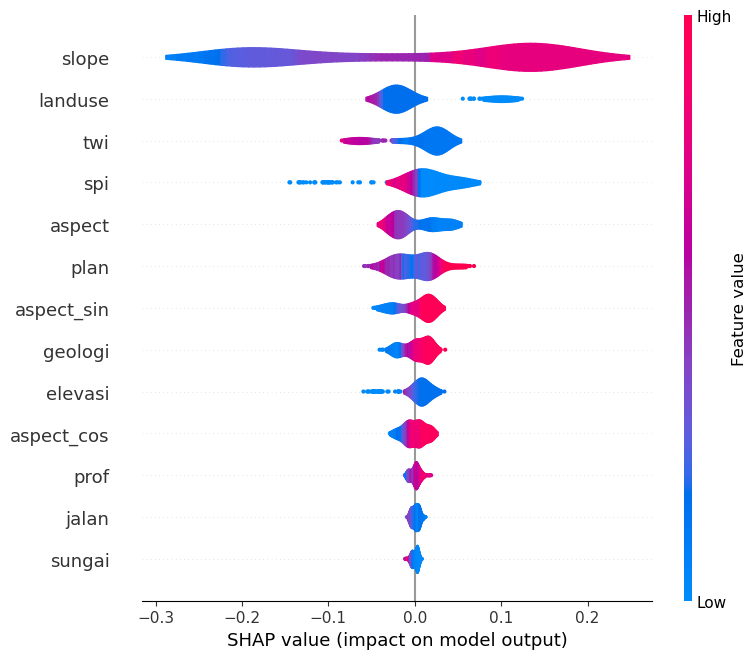

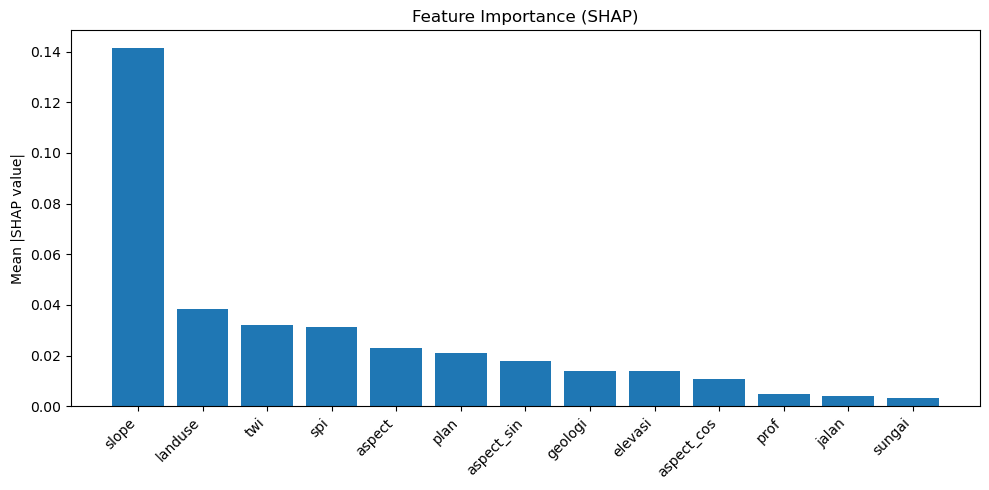

Top 2 features: slope, landuse


<Figure size 640x480 with 0 Axes>

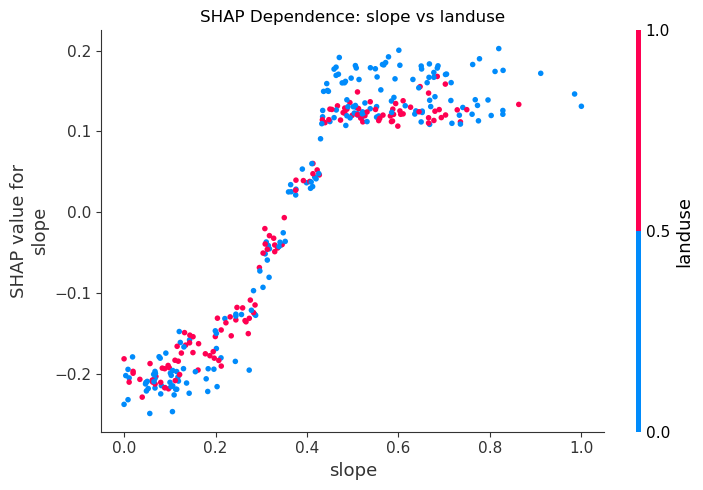

In [296]:
explainer, shap_vals, expected_val = tree_explainer(rf_final, X_test)

plot_shap_summary(shap_vals, X_test, feature_names=X_test.columns)
plot_feature_importance(shap_vals, X_test.columns, top_n=15)
plot_dependence_top2(shap_vals, X_test, X_test.columns)
plot_force(explainer, shap_vals, X_test, expected_val, index=10)

#### Perlokasi


SHAP - Lokasi: samodra_B
2


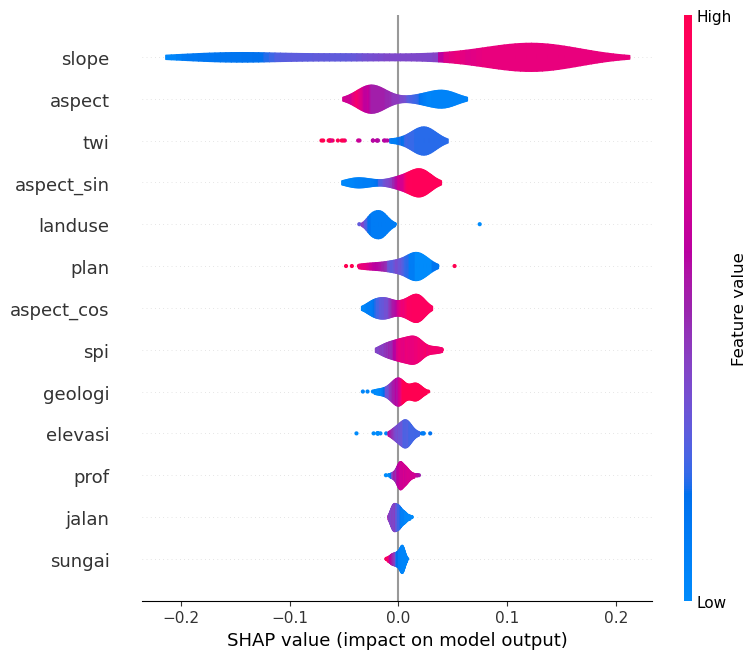

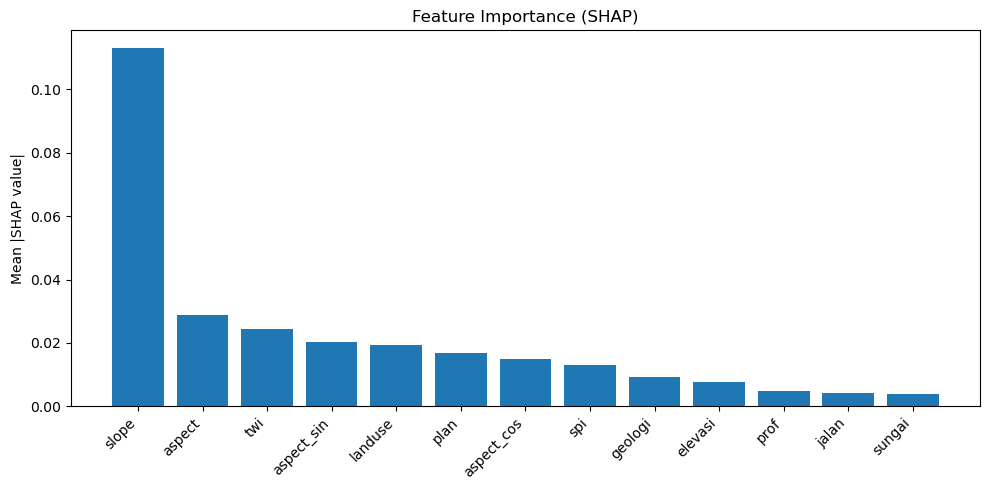

Top 2 features: slope, aspect


<Figure size 640x480 with 0 Axes>

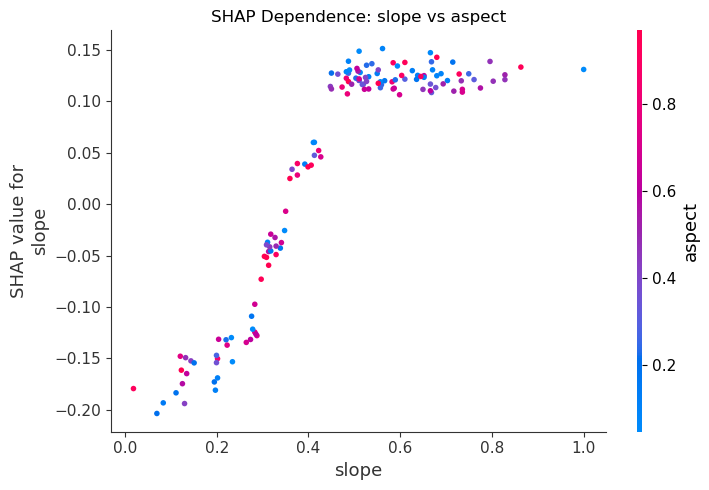


SHAP - Lokasi: mojokerto
2


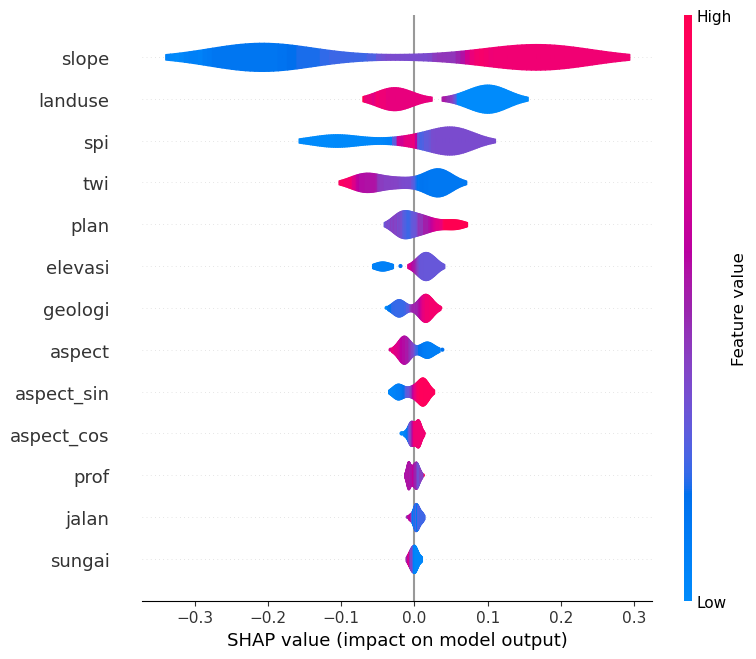

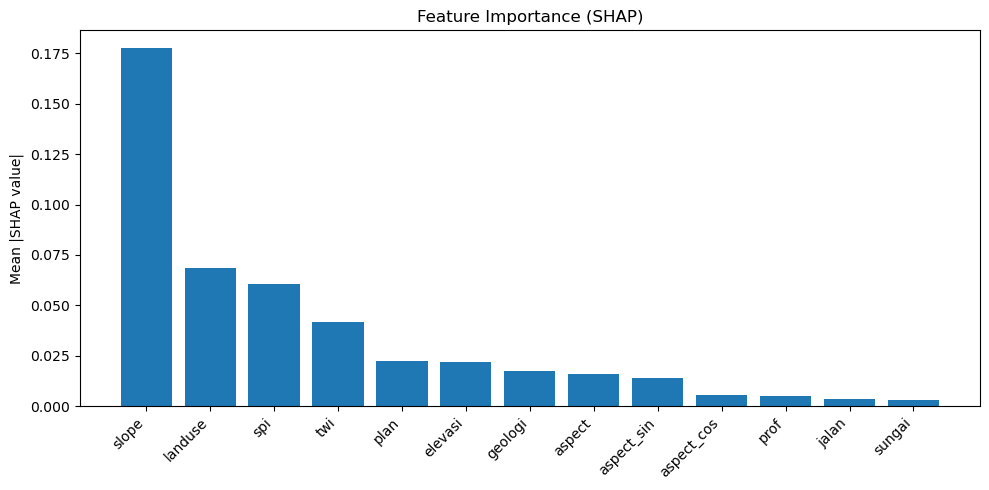

Top 2 features: slope, landuse


<Figure size 640x480 with 0 Axes>

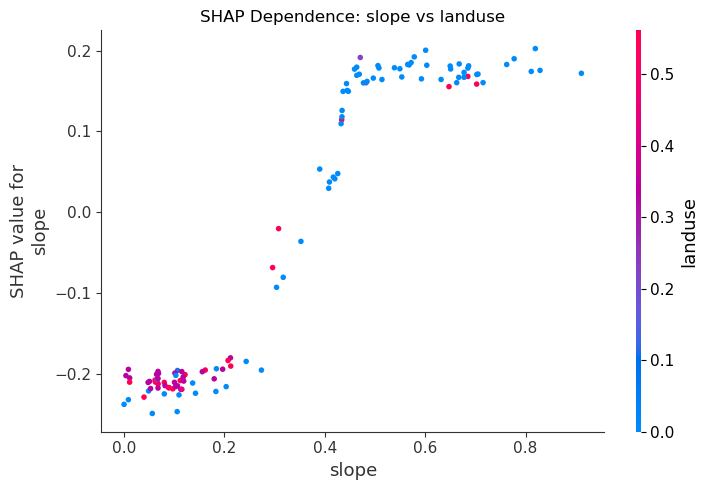


SHAP - Lokasi: samodra_A
2


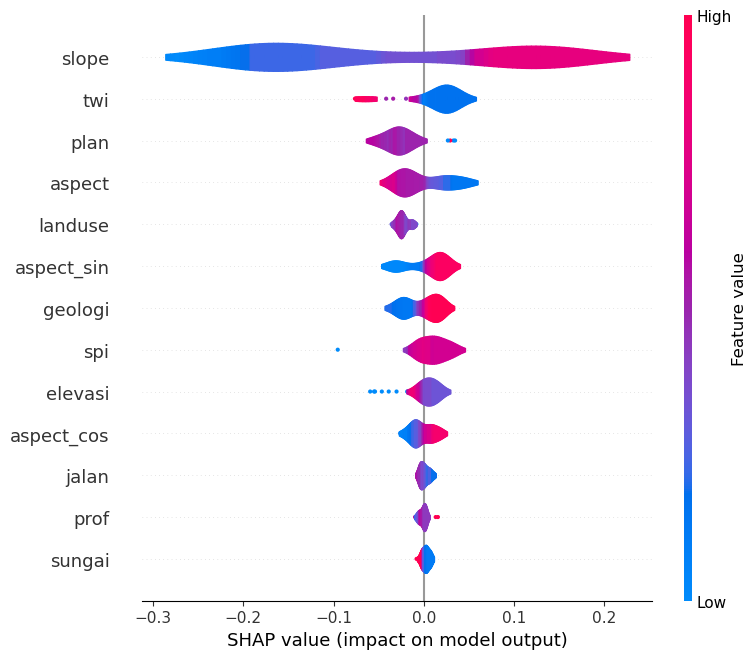

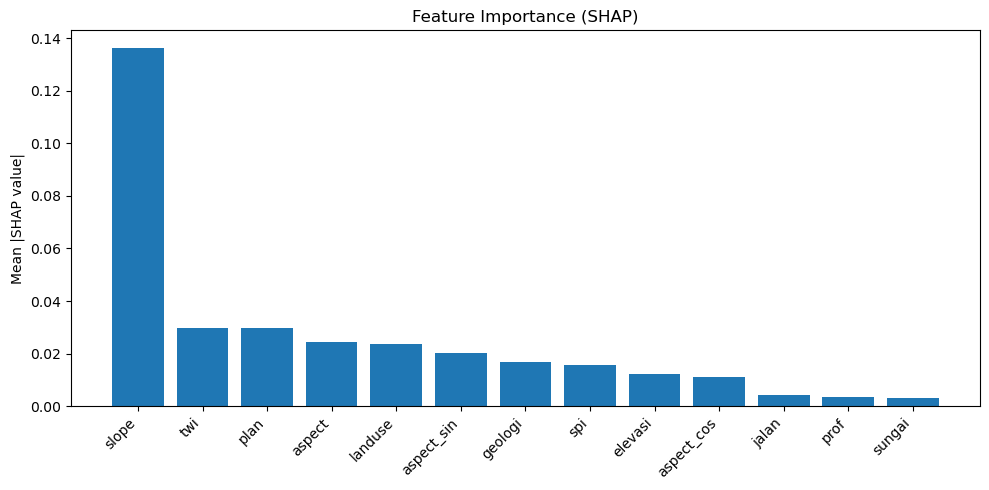

Top 2 features: slope, twi


<Figure size 640x480 with 0 Axes>

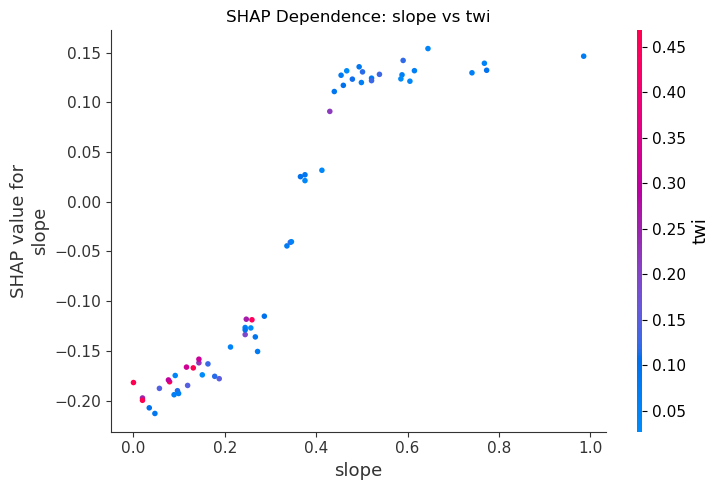

In [297]:
for loc in loc_test.unique():
    print(f"\n{'='*30}")
    print(f"SHAP - Lokasi: {loc}")
    print(f"{'='*30}")

    mask = (loc_test == loc)
    X_loc = X_test.loc[mask]

    _, shap_vals, expected_val = tree_explainer(rf_final, X_loc)

    plot_shap_summary(shap_vals, X_loc, feature_names=X_loc.columns)
    plot_feature_importance(shap_vals, X_loc.columns, top_n=15)
    plot_dependence_top2(shap_vals, X_loc, X_loc.columns)
    plot_force(explainer, shap_vals, X_loc, expected_val, index=10)


### GB

3


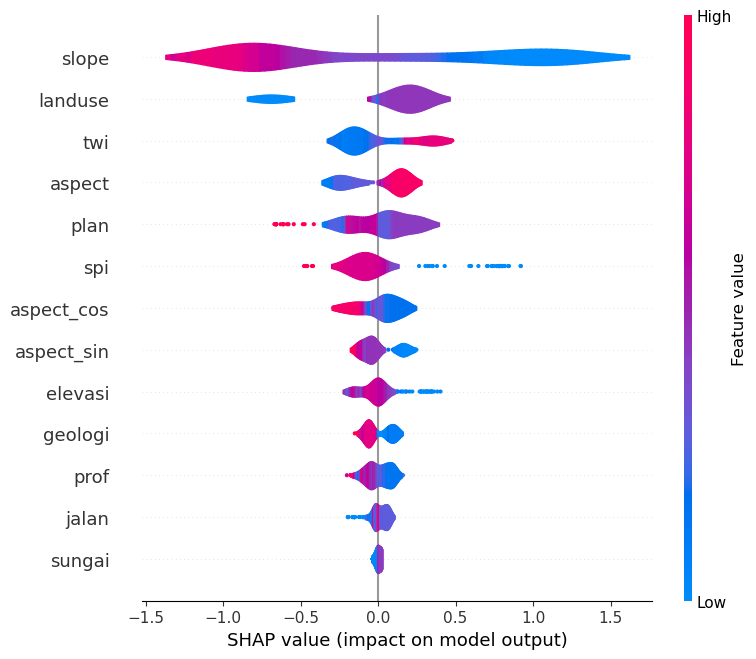

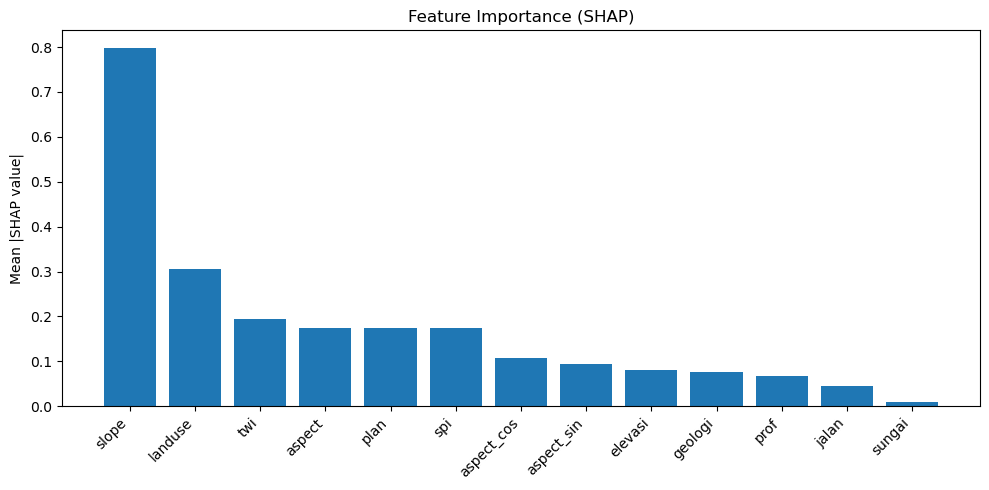

Top 2 features: slope, landuse


<Figure size 640x480 with 0 Axes>

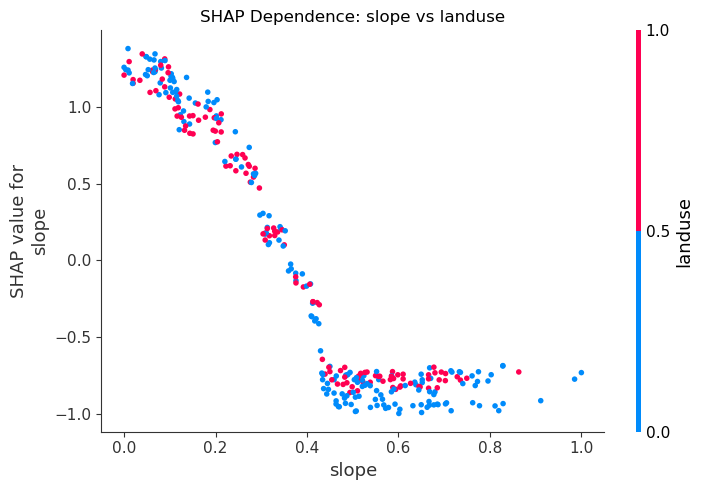

In [298]:
explainer, shap_vals, expected_val = tree_explainer(gb_final, X_test)

plot_shap_summary(shap_vals, X_test, feature_names=X_test.columns)
plot_feature_importance(shap_vals, X_test.columns, top_n=15)
plot_dependence_top2(shap_vals, X_test, X_test.columns)
plot_force(explainer, shap_vals, X_test, expected_val, index=10)

#### Perlokasi


SHAP - Lokasi: samodra_B
3


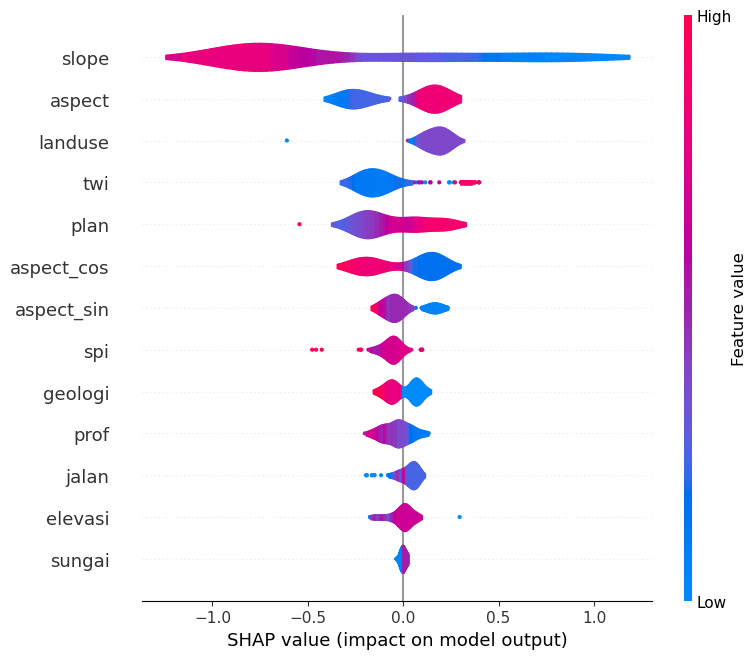

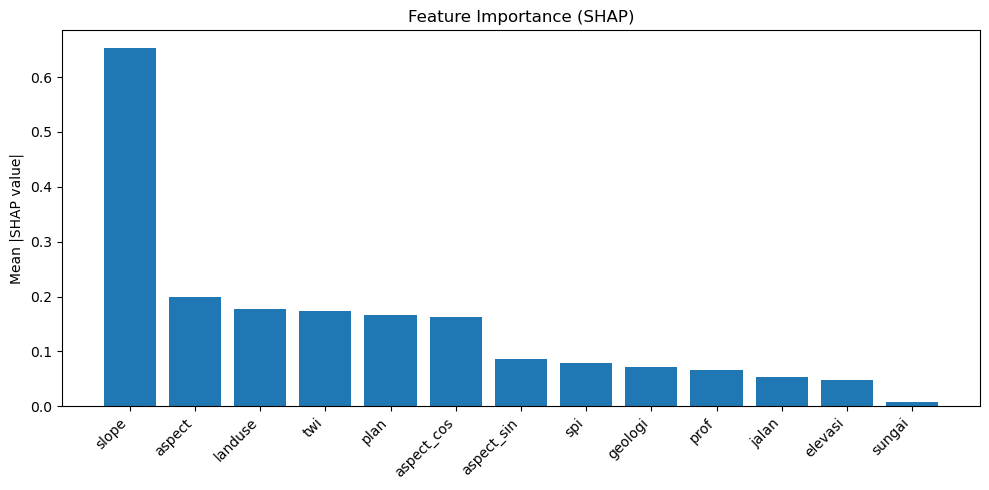

Top 2 features: slope, aspect


<Figure size 640x480 with 0 Axes>

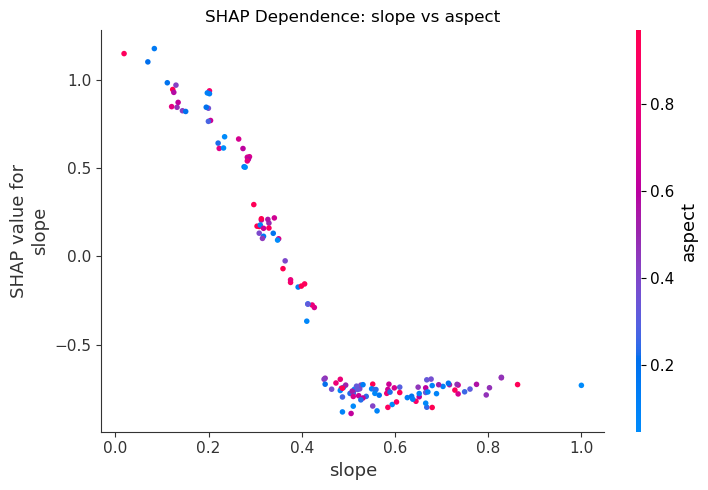


SHAP - Lokasi: mojokerto
3


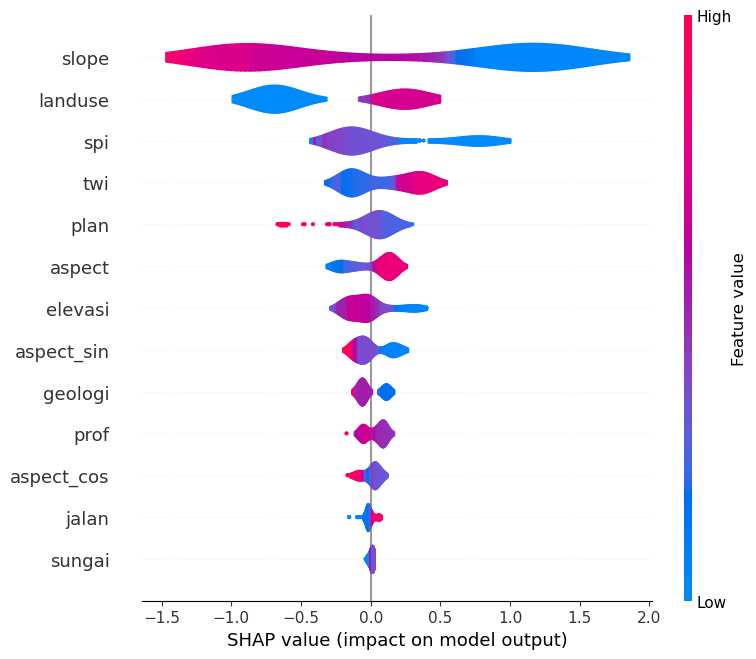

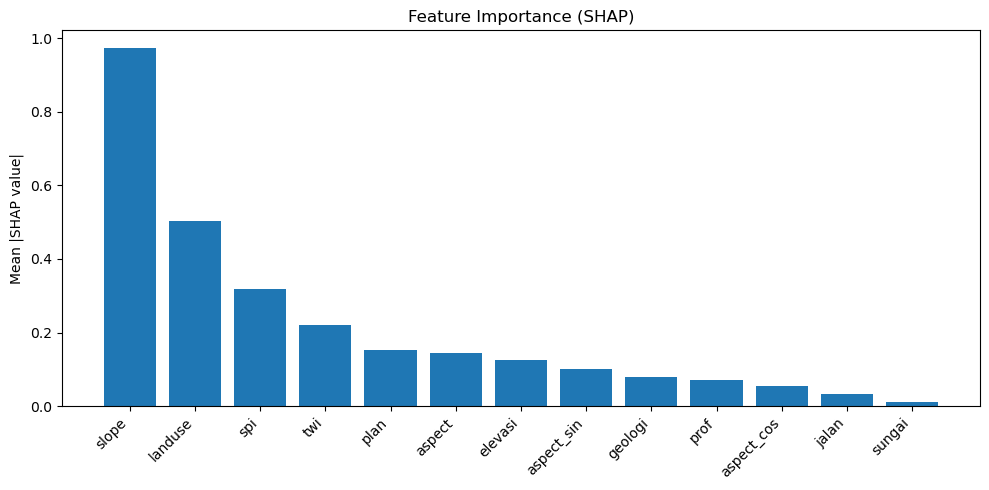

Top 2 features: slope, landuse


<Figure size 640x480 with 0 Axes>

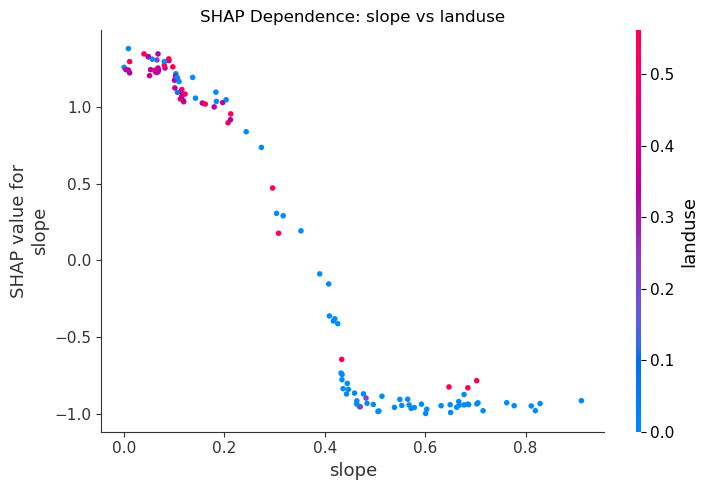


SHAP - Lokasi: samodra_A
3


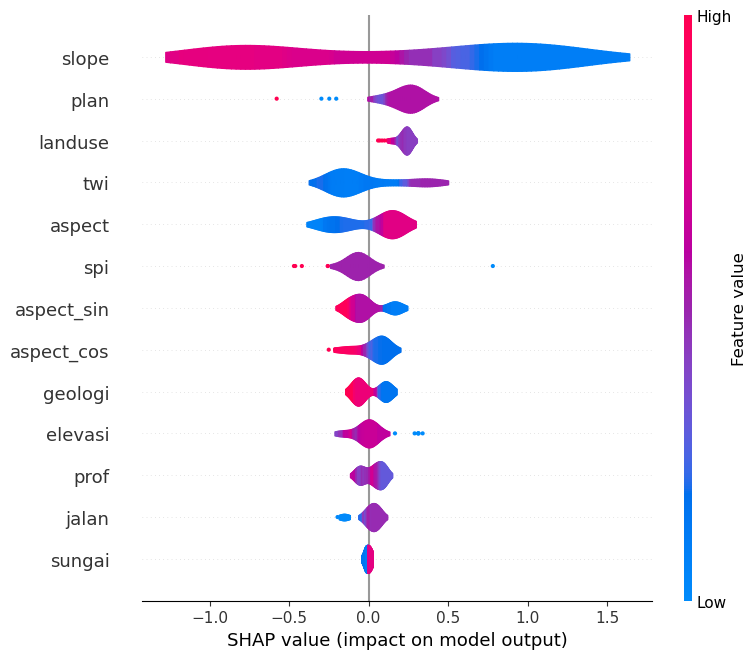

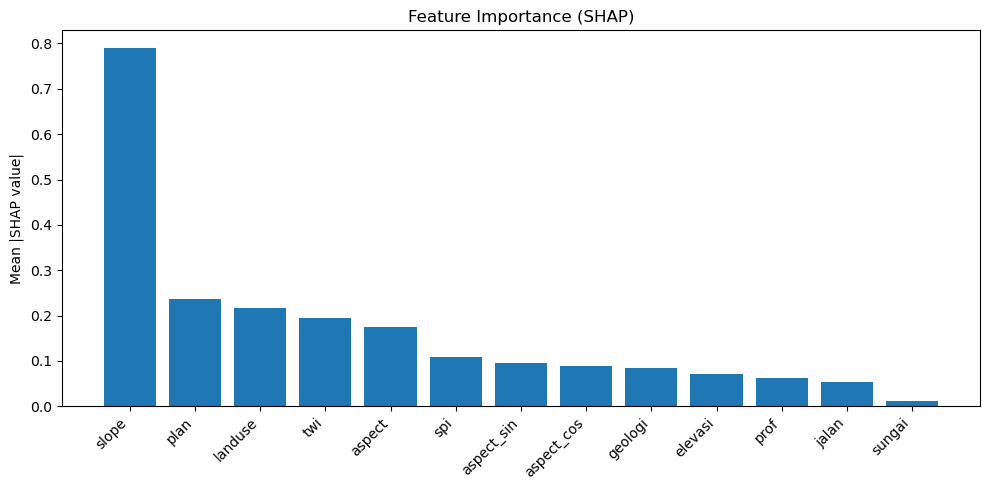

Top 2 features: slope, plan


<Figure size 640x480 with 0 Axes>

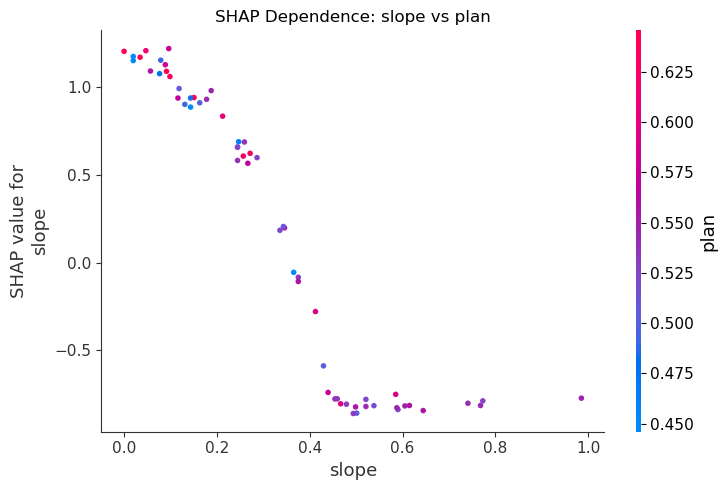

In [299]:
for loc in loc_test.unique():
    print(f"\n{'='*30}")
    print(f"SHAP - Lokasi: {loc}")
    print(f"{'='*30}")

    mask = (loc_test == loc)
    X_loc = X_test.loc[mask]

    _, shap_vals, expected_val = tree_explainer(gb_final, X_loc)

    plot_shap_summary(shap_vals, X_loc, feature_names=X_loc.columns)
    plot_feature_importance(shap_vals, X_loc.columns, top_n=15)
    plot_dependence_top2(shap_vals, X_loc, X_loc.columns)
    plot_force(explainer, shap_vals, X_loc, expected_val, index=10)
